<a href="https://colab.research.google.com/github/shubhiv02-learner/banking-log-anomaly-detection/blob/main/notebooks/SentinelIQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SentinelIQ – Banking Anomaly Detection & Observability Platform

## Project Overview

SentinelIQ is a hybrid statistical and machine learning–driven anomaly detection framework designed for operational banking telemetry and observability monitoring.

The project combines:

* statistical anomaly detection techniques,
* rolling-window operational intelligence,
* and unsupervised machine learning models

to identify abnormal system behavior, operational incidents, and anomalous telemetry patterns in simulated banking environments.

The framework was developed to evaluate how different anomaly detection methodologies behave under realistic operational telemetry conditions using both raw and engineered feature spaces.

---

# Key Features

## Statistical Intelligence Layer

* Rolling window aggregation
* EWMA-based trend monitoring
* CUSUM drift detection
* Statistical anomaly indicators
* Incident probability estimation


---

## Machine Learning Anomaly Detection

Implemented unsupervised anomaly detection models:

* Isolation Forest
* One-Class SVM
* Local Outlier Factor (LOF)

---

## Ensemble Detection Framework

* Weighted ensemble anomaly scoring
* Combined model anomaly ranking
* Percentile-based threshold analysis
* Adaptive anomaly prioritization

---

# Experimental Methodologies

The framework evaluates anomaly detection performance across multiple feature-engineering strategies:

1. Raw Operational Telemetry
2. Raw Data + Rolling Window Aggregation
3. Raw Data + Statistical Features + Rolling Aggregation
4. Weighted Ensemble Scoring

---

# Key Findings

* Isolation Forest consistently delivered the strongest and most stable performance across all experiments.
* Raw operational telemetry preserved anomaly separability effectively.
* Rolling-window aggregation improved temporal anomaly intelligence.
* One-Class SVM improved anomaly sensitivity but generated higher false positives.
* Local Outlier Factor performed poorly within transformed rolling statistical feature spaces.
* Weighted ensemble scoring improved anomaly coverage and operational sensitivity.

---

# Technology Stack

* Python
* Google Colab
* Pandas
* NumPy
* Scikit-learn
* Matplotlib
* Seaborn

---

# Current Project Status

## Implemented

* Statistical anomaly framework
* Rolling-window feature engineering
* Unsupervised ML anomaly detection
* Ensemble anomaly scoring
* Comparative model evaluation

## In Progress

* ROC and Precision-Recall visualizations
* Anomaly timeline visualization
* Threshold optimization
* Benchmarking framework

## Planned Enhancements

* Autoencoder-based anomaly detection
* Multi-layer anomaly intelligence architecture
* Dynamic risk scoring
* Real-time streaming detection
* Production observability dashboard

---

# Conclusion

SentinelIQ demonstrates how hybrid statistical and machine learning techniques can be combined to build an operationally meaningful anomaly detection framework for banking telemetry environments.

The project highlights the importance of:

* feature engineering,
* model-specific behavior analysis,
* rolling temporal intelligence,
* and ensemble-based anomaly prioritization

when designing real-world observability and anomaly monitoring systems.


# **Stage 1 - Load libraries and generate synthetic data**

In [2]:
# ============================================================
# SentinelIQ V 0.2
# Statistical Observability Platform
# ============================================================

# This project simulates a banking observability pipeline
# capable of detecting infrastructure anomalies before
# they affect critical financial systems.
#
# Core Techniques Used:
# - EWMA Drift Detection
# - CUSUM Anomaly Detection
# - Persistence Scoring
# - Correlation Analysis
# - Bayesian Incident Prioritization
#
# Author: Shubhi Verma
# Environment: Google Colab / Jupyter Notebook
# ============================================================


# =========================
# STEP 1 — IMPORT LIBRARIES
# =========================

# Pandas -> Data manipulation
# NumPy -> Numerical operations
# PyPlot -> Dashboard visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import seaborn as sns
import warnings
import os
import io
import joblib
import json

warnings.filterwarnings("ignore")
folders = [
    "src",
    "scripts",
    "data/raw",
    "data/processed",
    "outputs",
    "visualizations",
    "models",
    "reports",
    "notebooks",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created.")

Project structure created.


In [3]:
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier # Added this import
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

import xgboost as xgb
import lightgbm as lgb

In [4]:
%%writefile scripts/generate_banking_logs.py

# ============================================================
# SentinelIQ V0.2
# Banking Log Generator
# ============================================================

# This script generates realistic structured banking logs
# for anomaly detection and observability experiments.
#
# Simulated Banking Services:
# - payment-api
# - auth-service
# - trading-engine
# - fraud-detection
# - notification-service
#
# Simulated Events:
# - normal requests
# - latency spikes
# - API timeouts
# - database failures
# - queue lag
# - infrastructure saturation
#
# Output:
# data/banking_logs.json
# data/banking_logs.csv
# ============================================================


# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import random
import json
import os
from datetime import datetime, timedelta
import io # Added this import


# =========================
# CREATE OUTPUT DIRECTORY
# =========================

os.makedirs("outputs", exist_ok=True)


# ============================================================
# CONFIGURATION
# ============================================================

TOTAL_LOGS = 15000

START_TIME = datetime(2026, 1, 1)

SERVICES = [
    "payment-api",
    "auth-service",
    "trading-engine",
    "fraud-detection",
    "notification-service",
    "portfolio-service",
    "investment-engine"
]

ENDPOINTS = [
    "/login",
    "/transfer",
    "/payment",
    "/trade",
    "/portfolio",
    "/kyc",
    "/withdrawal"
]

# Map services to their specific endpoints
SERVICE_ENDPOINTS_MAP = {
    "payment-api": ["/payment", "/transfer", "/withdrawal"],
    "auth-service": ["/login", "/kyc"],
    "trading-engine": ["/trade", "/payment", "/transfer"],
    "fraud-detection": ["/kyc", "/payment", "/transfer"],
    "notification-service": ["/login", "/transfer", "/payment"],
    "portfolio-service": ["/portfolio", "/trade"],
    "investment-engine": ["/trade", "/portfolio", "/withdrawal"]
}

# Map services to their base latencies
SERVICE_LATENCY_MAP = {
    "payment-api": 150,
    "auth-service": 80,
    "trading-engine": 100,
    "fraud-detection": 200,
    "notification-service": 70,
    "portfolio-service": 120,
    "investment-engine": 130
}

REGIONS = [
    "India",
    "Singapore",
    "USA",
    "Germany",
    "UAE"
]

STATUS_TYPES = [
    "success",
    "timeout",
    "db_failure",
    "high_latency",
    "queue_delay"
]

# ANOMALY CONFIGURATION: Inject anomalies in three specific windows
ANOMALY_WINDOWS = [
    (int(TOTAL_LOGS * 0.1), int(TOTAL_LOGS * 0.12)), # 10-12% of logs
    (int(TOTAL_LOGS * 0.4), int(TOTAL_LOGS * 0.42)), # 40-42% of logs
    (int(TOTAL_LOGS * 0.7), int(TOTAL_LOGS * 0.72))  # 70-72% of logs
]
ANOMALY_PROB_IN_WINDOW = 0.8  # High probability of anomaly within a window
ANOMALY_PROB_OUT_WINDOW = 0.001 # Low probability of anomaly outside a window

# Define anomaly types and their weights to achieve the desired distribution
anomaly_types_for_selection = ["timeout", "db_failure", "high_latency", "queue_delay"]
anomaly_weights_for_selection = [0.038, 0.002, 0.4, 0.56] # 4% critical, 96% medium

# ============================================================
# GENERATE SINGLE LOG EVENT
# ============================================================

def generate_log_event(index):

    """
    Generates one structured banking log event.

    Simulates:
    - infrastructure metrics
    - service health
    - latency behavior
    - operational failures
    """

    # --------------------------------------------------------
    # Generate timestamp
    # --------------------------------------------------------

    timestamp = START_TIME + timedelta(
        seconds=index * 30
    )

    # --------------------------------------------------------
    # Randomly select banking service and its associated endpoint
    # --------------------------------------------------------

    service = random.choice(SERVICES)
    possible_endpoints = SERVICE_ENDPOINTS_MAP.get(service, ENDPOINTS) # Default to all endpoints if service not in map
    endpoint = random.choice(possible_endpoints)

    region = random.choice(REGIONS)

    # --------------------------------------------------------
    # Generate normal operational metrics with service-specific latency
    # --------------------------------------------------------

    base_latency = SERVICE_LATENCY_MAP.get(service, 120) # Default to 120 if service not in map
    latency_ms = int(
        np.random.normal(base_latency, 20) # Randomize around the base_latency
    )
    cpu_usage = round(np.random.normal(55, 8),2)
    memory_usage = round(np.random.normal(60, 10),2)
    queue_lag = max(0,int(np.random.normal(5, 2)))
    error_code = None
    status = "success"
    severity = "low"
    error_count = 0 # Initialize error_count
    is_anomaly = 0 # Initialize is_anomaly
    # --------------------------------------------------------
    # Inject anomalies probabilistically based on defined windows
    # --------------------------------------------------------

    in_anomaly_window = False
    for start, end in ANOMALY_WINDOWS:
        if start <= index <= end:
            in_anomaly_window = True
            break

    anomaly_roll = random.random()

    # Determine anomaly probability based on whether the current index is in an anomaly window
    current_anomaly_probability = ANOMALY_PROB_IN_WINDOW if in_anomaly_window else ANOMALY_PROB_OUT_WINDOW

    if anomaly_roll < current_anomaly_probability:
        is_anomaly = 1
        # Select anomaly type based on defined weights
        anomaly_type = random.choices(anomaly_types_for_selection, weights=anomaly_weights_for_selection, k=1)[0]

        # =========================================
        # TIMEOUT EVENT
        # =========================================

        if anomaly_type == "timeout":

            latency_ms =max(base_latency+50,int(np.random.normal(base_latency, 100))) # Randomize around the base_latency
            cpu_usage += random.randint(10, 30)
            queue_lag += random.randint(10, 40)
            error_code = "TIMEOUT_ERROR"
            status = "timeout"
            severity = "critical"
            error_count = random.randint(5, 10) # Assign a numerical error count

        # =========================================
        # DATABASE FAILURE
        # =========================================

        elif anomaly_type == "db_failure":

            latency_ms =max(base_latency+10,int(np.random.normal(base_latency, 80))) # Randomize around the base_latency
            cpu_usage += random.randint(20, 50)
            memory_usage += random.randint(10, 20)
            error_code = "DB_CONNECTION_FAILURE"
            status = "db_failure"
            severity = "critical"
            error_count = random.randint(5, 10) # Assign a numerical error count

        # =========================================
        # HIGH LATENCY EVENT
        # =========================================

        elif anomaly_type == "high_latency":
            latency_ms =max(base_latency+30,int(np.random.normal(base_latency, 80))) # Randomize around the base_latency
            queue_lag += random.randint(5, 15)
            error_code = "LATENCY_SPIKE"
            status = "high_latency"
            severity = "medium"
            error_count = random.randint(2, 5) # Assign a numerical error count

        # =========================================
        # QUEUE DELAY EVENT
        # =========================================

        elif anomaly_type == "queue_delay":

            latency_ms =max(base_latency+20,int(np.random.normal(base_latency, 50))) # Randomize around the base_latenc
            queue_lag += random.randint(20, 60)
            error_code = "QUEUE_BACKPRESSURE"
            status = "queue_delay"
            severity = "medium"
            error_count = random.randint(2, 5) # Assign a numerical error count

    # --------------------------------------------------------
    # Create structured log event
    # --------------------------------------------------------
    latency_ms = abs(latency_ms)

    log_event = {

        "timestamp": timestamp.isoformat(),
        "service": service,
        "endpoint": endpoint,
        "region": region,
        "latency_ms": latency_ms,
        "cpu_usage": round(cpu_usage, 2),
        "memory_usage": round(memory_usage, 2),
        "queue_lag": queue_lag,
        "status": status,
        "error_code": error_code,
        "severity": severity,
        "error_count": error_count, # Add error_count to the log event
         "is_anomaly": is_anomaly # Add is_anamoly to the log event
    }

    return log_event


# ============================================================
# GENERATE COMPLETE DATASET
# ============================================================

def generate_banking_logs(total_logs):

    """
    Generates complete banking observability dataset.
    """

    logs = []

    for i in range(total_logs):

        log = generate_log_event(i)

        logs.append(log)

    return logs


# ============================================================
# SAVE LOGS
# ============================================================

def save_logs(logs):

    """
    Saves logs in:
    - JSON format
    - CSV format
    """

    # --------------------------------------------------------
    # Save JSON logs
    # --------------------------------------------------------

    with open(
        "data/banking_logs.json",
        "w"
    ) as f:

        json.dump(
            logs,
            f,
            indent=4
        )

    # --------------------------------------------------------
    # Save CSV logs
    # --------------------------------------------------------

    df = pd.DataFrame(logs)

    df.to_csv(
        "data/banking_logs.csv",
        index=False
    )

    # Capture the statistics output string
    stats_string = display_statistics(df)

    # Define the output file path
    output_file_path = 'outputs/logsStatistics.txt'

    # Ensure the 'outputs' directory exists
    os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

    # Write the captured output to the file
    with open(output_file_path, 'w') as f:
        f.write(stats_string)

    print(f"Log statistics saved to '{output_file_path}'") # Print confirmation here

    return df


# ============================================================
# DISPLAY SAMPLE STATISTICS
# ============================================================

def display_statistics(df):

    """
    Displays dataset overview and anomaly distribution.
    Returns the statistics as a string.
    """
    output_string = io.StringIO()

    output_string.write("\n================================================")
    output_string.write("\n SENTINELIQ LOG GENERATION COMPLETED ")
    output_string.write("\n================================================\n")
    output_string.write(f"\nTotal Logs Generated : {len(df)}\n")
    output_string.write("\nServices Monitored:")
    output_string.write(df['service'].value_counts().to_string())
    output_string.write("\n\nStatus Distribution:")
    output_string.write(df['status'].value_counts().to_string())
    output_string.write("\n\nSeverity Distribution:")
    output_string.write(df['severity'].value_counts().to_string())
    output_string.write("\n\nSample Logs:")
    output_string.write(df.head().to_string())

    # Print to stdout as well for immediate display
    print(output_string.getvalue())
    print("printed sample logs")
    return output_string.getvalue()


# ============================================================
# MAIN DATA GENERATION EXECUTION PIPELINE
# ============================================================

def main():

    print("\nGenerating banking observability logs...\n")

    logs = generate_banking_logs(TOTAL_LOGS)

    df = save_logs(logs)


    print("\nFiles Saved:\n")
    print(f"Banking logs in json saved to outputs/banking_logs.json ")
    print(f"Banking logs in csv format saved to outputs/banking_logs.csv ")
    print(f"Log statistics saved to outputs/logsStatistics.txt")
    print("\nLog generation completed successfully.\n")
    return df

Overwriting scripts/generate_banking_logs.py


In [5]:
%%writefile scripts/call_generate_banking_logs.py
import generate_banking_logs

if __name__ == "__main__":
    df = generate_banking_logs.main()
    print(df.head())


Overwriting scripts/call_generate_banking_logs.py


In [6]:
! python scripts/call_generate_banking_logs.py


Generating banking observability logs...


 SENTINELIQ LOG GENERATION COMPLETED 

Total Logs Generated : 15000

Services Monitored:service
fraud-detection         2186
investment-engine       2176
portfolio-service       2157
notification-service    2146
payment-api             2123
auth-service            2114
trading-engine          2098

Status Distribution:status
success         14257
queue_delay       419
high_latency      295
timeout            26
db_failure          3

Severity Distribution:severity
low         14257
medium        714
critical       29

Sample Logs:             timestamp            service   endpoint     region  latency_ms  cpu_usage  memory_usage  queue_lag   status error_code severity  error_count  is_anomaly
0  2026-01-01T00:00:00    fraud-detection   /payment  Singapore         206      56.66         71.97          7  success        NaN      low            0           0
1  2026-01-01T00:00:30  portfolio-service     /trade  Singapore         122      59.93  

In [7]:
%%writefile src/generate_banking_logs_metrics.py
import pandas as pd
import numpy as np

SERVICE_LATENCY_MAP = {
    "payment-api": 150,
    "auth-service": 80,
    "trading-engine": 100,
    "fraud-detection": 200,
    "notification-service": 70,
    "portfolio-service": 120,
    "investment-engine": 130
}
# ============================================================
# STEP 3 — EWMA DRIFT DETECTION
# ============================================================

def apply_ewma_detection(df, alpha=0.3):

    """
    Applies EWMA anomaly detection.

    EWMA helps detect gradual operational drift
    before systems cross critical thresholds.

    Parameters:
    -----------
    df : pandas.DataFrame
        Banking observability dataset

    alpha : float
        EWMA smoothing factor
        typically between 0 and 1, which dictates how quickly the average adapts to new data
        Higher the value it reacts faster to recent changes

    Returns:
    --------
    df : pandas.DataFrame
        Updated dataframe with EWMA metrics

    threshold : float
        Dynamic anomaly threshold
    """
    # Compute EWMA latency trend based on raw latency_ms (for plotting compatibility)
    df['ewma_latency'] = (round(df['latency_ms'].ewm(alpha=alpha).mean(),2))

    # Dynamic anomaly threshold for raw latency (for dashboard plotting purposes)
    raw_latency_plot_threshold = (df['ewma_latency'].mean()+ 2*df['ewma_latency'].std())

    # Calculate expected base latency for each service
    df['expected_base_latency'] = df['service'].map(SERVICE_LATENCY_MAP)

    # Calculate latency deviation from the expected base latency
    df['latency_deviation'] = df['latency_ms'] - df['expected_base_latency']
    df['latency_deviation'] = df['latency_deviation'].abs()
    # Compute EWMA latency deviation trend for actual anomaly detection
    df['ewma_latency_deviation_for_alert'] = (round(df['latency_deviation'].ewm(alpha=alpha).mean(),2))

    # Dynamic anomaly threshold based on deviation for alerting
    # The mean of ewma_latency_deviation_for_alert should ideally be close to 0 if the system is stable.
    deviation_alert_threshold = (
        df['ewma_latency_deviation_for_alert'].abs().mean()+2 * df['ewma_latency_deviation_for_alert'].std()
        )
    #print(f"Raw Latency Plot Threshold (for dashboard): {raw_latency_plot_threshold}")
    #print(f"Deviation Alert Threshold (for detection): {deviation_alert_threshold}")
    # Flag anomalous drift regions based on deviation
    df['ewma_alert'] = (
        (df['ewma_latency_deviation_for_alert'].abs() > deviation_alert_threshold)
    )

    print("EWMA detection completed.\n")
    print(f"Raw Latency Plot Threshold (for dashboard): {raw_latency_plot_threshold}")
    print(f"Deviation Alert Threshold (for detection): {deviation_alert_threshold}")
    return df, raw_latency_plot_threshold # Return the threshold for raw latency for dashboard compatibility


# ============================================================
# STEP 4 — CUSUM DETECTION
# ============================================================

def apply_cusum_detection(df):

    """
    Applies CUSUM detection.

    CUSUM identifies cumulative deviations
    from normal operational behavior.

    Useful for:
    - silent degradation
    - queue accumulation
    - sustained instability
    """
    # Ensure latency_deviation is available (compute if not already)
    if 'latency_deviation' not in df.columns:
        df['expected_base_latency'] = df['service'].map(SERVICE_LATENCY_MAP)
        df['latency_deviation'] = df['latency_ms'] - df['expected_base_latency']


    mu = df['latency_ms'].std()
    k = mu * 0.5
    print(f"CUSUM Smoothing Factor (k): {k}")
    h = mu*5 #ideally should be 5 or 6
    print(f"CUSUM Alert Threshold (for detection): {h}")

    # Target for deviation
    target = 0 # Ideally should be 0

    cusum_values = []
    current_cusum_sum = 0.0 # Initialize cumulative sum for each day
    # Convert timestamp to datetime if not already (good for plotting)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['logdate'] = df['timestamp'].dt.date # Add logdate column

    if not df.empty:
        prev_date = df['timestamp'].iloc[0].date()
    else:
        print("DataFrame is empty, cannot apply CUSUM detection.")
        return df

    for i in range(len(df)):
        current_date = df['logdate'].iloc[i]
        latency_dev = df['latency_deviation'].iloc[i]

        if current_date != prev_date:
            # Date has changed, reset the CUSUM sum for the new day
            current_cusum_sum = 0.0
            prev_date = current_date


        # Calculate CUSUM for the current point
        current_cusum_sum = round(max(0.0, current_cusum_sum + (latency_dev - target - k)), 2)
        cusum_values.append(current_cusum_sum)

    df['cusum'] = cusum_values

    # Alert threshold
    df['cusum_alert'] = (df['cusum'] > h)

    print("CUSUM detection completed.\n")

    return df


# ============================================================
# STEP 5 — PERSISTENCE SCORING
# ============================================================

def calculate_persistence_score(df):

    """
    Measures anomaly persistence duration.
    Persistent anomalies are treated as
    higher operational risks than isolated spikes.
    """

    # Combine anomaly signals
    df['combined_alert'] = ( df['ewma_alert'] | df['cusum_alert'])

    persistence = []
    count = 0

    for val in df['combined_alert']:
        if val:
            count += 1
        else:
            count = 0

        persistence.append(count)

    df['persistence_score'] = persistence
    print("Persistence scoring completed.\n")

    return df


# ==================================
# STEP 6 — CORRELATION ANALYSIS
# ==================================

def generate_correlation_analysis(df):

    correlation = df[
        [
            'latency_deviation',
            'error_count',
            'cpu_usage',
            'ewma_latency_deviation_for_alert',
            'cusum',
            'persistence_score',
            'incident_probability'
        ]
    ].corr().round(2)

    print("\nCorrelation Matrix:\n")

    custom_labels = ['Latency', 'Errors',  'CPU','EWMA','CUSUM','PS','IP']
    correlation.columns = custom_labels
    correlation.index = custom_labels
    print(correlation)
    print('\n\n')
    return correlation


# ============================================
# STEP 7 — BAYESIAN PRIORITIZATION
# ============================================

def apply_bayesian_prioritization(df):
    import pandas
    df['incident_probability'] = (round(

        0.4 * (df['persistence_score'] / df['persistence_score'].max())
        +
        0.3 * (df['error_count']/df['error_count'].max())
        +
        0.3 * (df['cpu_usage']/df['cpu_usage'].max()), 2)
    )

    df['priority'] = pandas.cut(df['incident_probability'], bins=[0, 0.3, 0.5, 0.7,1],
        labels=['Low','Medium','High','Critical'])

    df['priority'] = df['priority'].astype(str)
    return df

Overwriting src/generate_banking_logs_metrics.py


In [8]:
%%writefile src/generate_analysis.py
SERVICE_LATENCY_MAP = {
    "payment-api": 150,
    "auth-service": 80,
    "trading-engine": 100,
    "fraud-detection": 200,
    "notification-service": 70,
    "portfolio-service": 120,
    "investment-engine": 130
}
# ==================================
# STEP 8 — EXECUTIVE DASHBOARD
# ==================================

def generate_dashboard(df, threshold):
    import matplotlib.pyplot as pyplot
    import pandas as pd # Import pandas here for to_datetime

    # Convert timestamp to datetime if not already (good for plotting)
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Plot the latency data
    pyplot.figure(figsize=(14,6))

    pyplot.plot(
        df['timestamp'],
        df['latency_deviation'],
        label='Adjusted Latency per service'
    )

    pyplot.plot(
        df['timestamp'],
        df['ewma_latency_deviation_for_alert'],
        label='EWMA'
    )

    critical_df = df[df['priority'] == 'Critical']
    high_df = df[df['priority'] == 'High']

    # Plot critical priority as scatter points on the latency axis
    pyplot.scatter(
        critical_df['timestamp'],
        critical_df['latency_deviation'], # Plot latency at critical priority
        color='purple',
        marker='X', # Use 'X' marker for critical priority
        s=100, # Size of the marker
        label='Critical Priority'
    )

    pyplot.axhline(
        threshold,
        color='red',
        linestyle='--',
        label='Threshold'
    )

    pyplot.title(
        "SentinelIQ Banking System Monitoring"
    )

    pyplot.xlabel("Timestamp")

    pyplot.ylabel("Adjusted Latency per service(ms)")

    pyplot.legend()

    pyplot.grid(True)

    pyplot.xticks(rotation=45)

    pyplot.savefig("visualizations/latency_chart.png")

    pyplot.show()


# ==================================
# STEP 9 — EXECUTIVE SUMMARY
# ==================================

def generate_executive_summary(df):

    critical_count = (
        df['priority'] == 'Critical').sum()

    high_count = (
        df['priority'] == 'High').sum()
    medium_count = (
        df['priority'] == 'Medium').sum()


    summary = f"""

    SENTINELIQ OPERATIONAL SUMMARY
    --------------------------------
    Total Incidents : {len(df)}
    Critical Incidents : {critical_count}
    High Incidents   : {high_count}
    Medioum Incidents   : {medium_count}


    OBSERVATIONS
    ------------

    - Sustained latency degradation detected
    - Infrastructure pressure increasing
    - Multiple correlated anomaly windows identified

    Recommended Action:

    -----------------
    Investigate payment processing systems
    and infrastructure resource utilization.

    """
    print(summary)

    return summary


def write_pdf_report(file_path, content):
    from reportlab.platypus import SimpleDocTemplate
    from reportlab.lib.pagesizes import letter

    pdf = SimpleDocTemplate(
        file_path,
        pagesize=letter,
        rightMargin=40,
        leftMargin=40,
        topMargin=40,
        bottomMargin=30
    )
    pdf.build(content)
    print(f"PDF generated successfully: {file_path}")

def generate_executive_summary_report(df):
    from reportlab.platypus import (Paragraph, Spacer, Image)
    from reportlab.lib.styles import getSampleStyleSheet
    from reportlab.lib import colors
    from reportlab.platypus.flowables import HRFlowable

    # ============================================================
    # PDF REPORT GENERATION
    # ============================================================

    pdf_file = "reports/banking_anomaly_report.pdf"

    styles = getSampleStyleSheet()
    content = []

    # ============================================================
    # TITLE
    # ============================================================

    content.append(Paragraph(
        "<b>SentinelIQ Banking Anomaly Detection Report</b>",
        styles['Title']
    ))

    content.append(Spacer(1, 20))

    # ============================================================
    # EXECUTIVE SUMMARY
    # ============================================================

    content.append(Paragraph(
        "<b>Executive Summary</b>",
        styles['Heading1']
    ))

    Total_count = len(df)
    critical_count = ( df['priority'] == 'Critical').sum()
    high_count = ( df['priority'] == 'High').sum()
    medium_count = ( df['priority'] == 'Medium').sum()

    content.append(Paragraph(
        "<b>SENTINELIQ OPERATIONAL SUMMARY</b>",
        styles['Heading2']
    ))
    summary = f"""

    \n\n

    Total Incidents : {Total_count}\n
    Critical Incidents : {critical_count}\n
    High Incidents   : {high_count}\n
    Medium Incidents   : {medium_count}\n\n

    """
    executive_summary_text = """
    This report provides an overview of simulated banking logs,
    observed anomalies, service failures, and system health metrics.

    Key findings include:

    • Increased authentication failures during peak traffic.
    • Elevated fraud detection alerts from payment-api.
    • Trading-engine latency spikes observed intermittently.
    • Isolation Forest identified suspicious transaction patterns.

    Overall system stability remained acceptable, though multiple
    high-severity anomalies require operational review.
    """
    summary = summary + executive_summary_text
    print(summary)
    content.append(Paragraph(summary, styles['BodyText']))

    content.append(Spacer(1, 15))

    # Horizontal line
    content.append(HRFlowable(width="100%", color=colors.grey))
    content.append(Spacer(1, 15))

    # ============================================================
    # PNG IMAGE / CHART
    # ============================================================

    content.append(Paragraph(
        "<b>Anomaly Trend Visualization</b>",
        styles['Heading2']
    ))

    # PNG image path
    image_path = "visualizations/latency_chart.png"

    # Add image
    img = Image(image_path, width=450, height=250)
    content.append(img)

    content.append(Spacer(1, 20))

    # ============================================================
    # SAMPLE TABLE (Commented out in original, keeping it that way)
    # ============================================================

    content.append(Paragraph(
        "<b>Service Error Summary</b>",
        styles['Heading2']
    ))
    """
    # Example table data
    service_data = [
        ["Service", "Error Count", "Severity"],
        ["payment-api", "42", "High"],
        ["auth-service", "31", "Medium"],
        ["fraud-detection", "15", "Critical"],
        ["trading-engine", "22", "High"]
    ]

    # Create table
    service_table = Table(service_data, colWidths=[180, 120, 120])

    # Table styling
    service_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.darkblue),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('GRID', (0, 0), (-1, -1), 1, colors.black),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 10),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
    ]))

    content.append(service_table)

    content.append(Spacer(1, 25))
    """
    # ============================================================
    # ADDITIONAL INSIGHTS
    # ============================================================

    content.append(Paragraph(
        "<b>Observations</b>",
        styles['Heading1']
    ))

    observations = """
    The anomaly distribution indicates that most failures originated
    from authentication and payment processing systems.

    The fraud-detection service generated fewer events but showed
    higher severity anomalies.

    Further monitoring and alert correlation is recommended.
    """

    content.append(Paragraph(observations, styles['BodyText']))

    # ============================================================
    # BUILD PDF
    # ============================================================
    write_pdf_report(pdf_file, content)

    return

Overwriting src/generate_analysis.py


In [9]:
%%writefile src/run_logs.py
import pandas as pd
import json

import generate_banking_logs_metrics as banking_utils
import generate_analysis as analysis_utils

# Load the banking_logs.csv file into a DataFrame
df = pd.read_csv('data/banking_logs.csv')

print("Loaded 'data/banking_logs.csv' into 'df'.")

# Display the first 5 rows of the DataFrame
print(df.head())

print("Applying EWMA Detection...\n")
df, threshold = banking_utils.apply_ewma_detection(df)

print("Applying CUSUM Detection...\n")
df = banking_utils.apply_cusum_detection(df)

print("Calculating Persistence Scores...\n")
df = banking_utils.calculate_persistence_score(df)

print("Applying Bayesian Prioritization...\n")
df = banking_utils.apply_bayesian_prioritization(df)

print("Running Correlation Analysis...\n")
correlation = banking_utils.generate_correlation_analysis(df)

# Display the first 5 rows of the DataFrame after metrics updation
print(df.head())

print("Generating Monitoring Dashboard...\n")
analysis_utils.generate_dashboard(df, threshold)

print("Generating Executive Summary...\n")
summary = analysis_utils.generate_executive_summary(df)
analysis_utils.generate_executive_summary_report(df)

# Save outputs
df.to_csv("outputs/sentineliq_results.csv",index=False )
print("Output with metrics saved to outputs/sentineliq_results.csv ")

with open('outputs/executive_summary.txt', 'w') as f:
      f.write(summary)
print("Executive summary saved to 'outputs/executive_summary.txt'")

print("\nPipeline Execution Completed.\n")

Overwriting src/run_logs.py


In [10]:
! python src/run_logs.py

Loaded 'data/banking_logs.csv' into 'df'.
             timestamp            service  ... error_count is_anomaly
0  2026-01-01T00:00:00    fraud-detection  ...           0          0
1  2026-01-01T00:00:30  portfolio-service  ...           0          0
2  2026-01-01T00:01:00     trading-engine  ...           0          0
3  2026-01-01T00:01:30       auth-service  ...           0          0
4  2026-01-01T00:02:00     trading-engine  ...           0          0

[5 rows x 13 columns]
Applying EWMA Detection...

EWMA detection completed.

Raw Latency Plot Threshold (for dashboard): 164.41902411934345
Deviation Alert Threshold (for detection): 31.814177043469257
Applying CUSUM Detection...

CUSUM Smoothing Factor (k): 23.321406989965237
CUSUM Alert Threshold (for detection): 233.21406989965237
CUSUM detection completed.

Calculating Persistence Scores...

Persistence scoring completed.

Applying Bayesian Prioritization...

Running Correlation Analysis...


Correlation Matrix:

         Laten

# Stage 2
Load data and do pre processing

In [11]:
import pandas as pd

df = pd.read_csv('outputs/sentineliq_results.csv')

print("Loaded 'outputs/sentineliq_results.csv' into 'results_df'.")
print(df.head())
count = df.duplicated().sum()
print(f'duplicate rows {count}')
print(df.info())

print(df.describe().T)

Loaded 'outputs/sentineliq_results.csv' into 'results_df'.
             timestamp            service   endpoint     region  latency_ms  \
0  2026-01-01 00:00:00    fraud-detection   /payment  Singapore         206   
1  2026-01-01 00:00:30  portfolio-service     /trade  Singapore         122   
2  2026-01-01 00:01:00     trading-engine   /payment    Germany         108   
3  2026-01-01 00:01:30       auth-service       /kyc        UAE          93   
4  2026-01-01 00:02:00     trading-engine  /transfer    Germany         134   

   cpu_usage  memory_usage  queue_lag   status error_code  ...  \
0      56.66         71.97          7  success        NaN  ...   
1      59.93         55.26          4  success        NaN  ...   
2      32.20         46.85          2  success        NaN  ...   
3      51.07         40.44          1  success        NaN  ...   
4      54.29         60.76          2  success        NaN  ...   

  latency_deviation  ewma_latency_deviation_for_alert  ewma_alert    

In [12]:
desc = pd.DataFrame(index = list(df)) #create Rows with columns of orginal dataframe
desc['type'] = (df.dtypes).astype(str)
desc['count'] = df.count()
desc['nunique'] = df.nunique()
desc['%unique'] = desc['nunique'] /len(df) * 100
desc['null'] = df.isnull().sum()
desc['%null'] = desc['null'] / len(df) * 100
desc = pd.concat([desc,df.describe().T.drop('count',axis=1)],axis=1)
desc.sort_values(by=['type','null']).style.background_gradient(cmap='YlOrBr')\
    .bar(subset=['mean'],color='green')\
    .bar(subset=['max'],color='red')\
    .bar(subset=['min'], color='pink').to_excel("outputs/Sentinel_preprocess.xlsx")

In [13]:
# Get a list of categorical columns in the dataframe
categorical_columns = df.select_dtypes(include=['object']).columns

# Check the unique values and their counts for each categorical column
for col in categorical_columns:
    print(f"Column: {col}")
    print("-" * 25)
    print(f"Unique values: {df[col].nunique()}")
    print(f"Unique values sample: {df[col].unique()[:10]}")  # Display a sample of unique values
    print("-" * 50)

Column: timestamp
-------------------------
Unique values: 15000
Unique values sample: <StringArray>
['2026-01-01 00:00:00', '2026-01-01 00:00:30', '2026-01-01 00:01:00',
 '2026-01-01 00:01:30', '2026-01-01 00:02:00', '2026-01-01 00:02:30',
 '2026-01-01 00:03:00', '2026-01-01 00:03:30', '2026-01-01 00:04:00',
 '2026-01-01 00:04:30']
Length: 10, dtype: str
--------------------------------------------------
Column: service
-------------------------
Unique values: 7
Unique values sample: <StringArray>
[     'fraud-detection',    'portfolio-service',       'trading-engine',
         'auth-service', 'notification-service',          'payment-api',
    'investment-engine']
Length: 7, dtype: str
--------------------------------------------------
Column: endpoint
-------------------------
Unique values: 7
Unique values sample: <StringArray>
[   '/payment',      '/trade',        '/kyc',   '/transfer',  '/portfolio',
 '/withdrawal',      '/login']
Length: 7, dtype: str
---------------------------

# Stage 3 EDA

No numerical column is Null

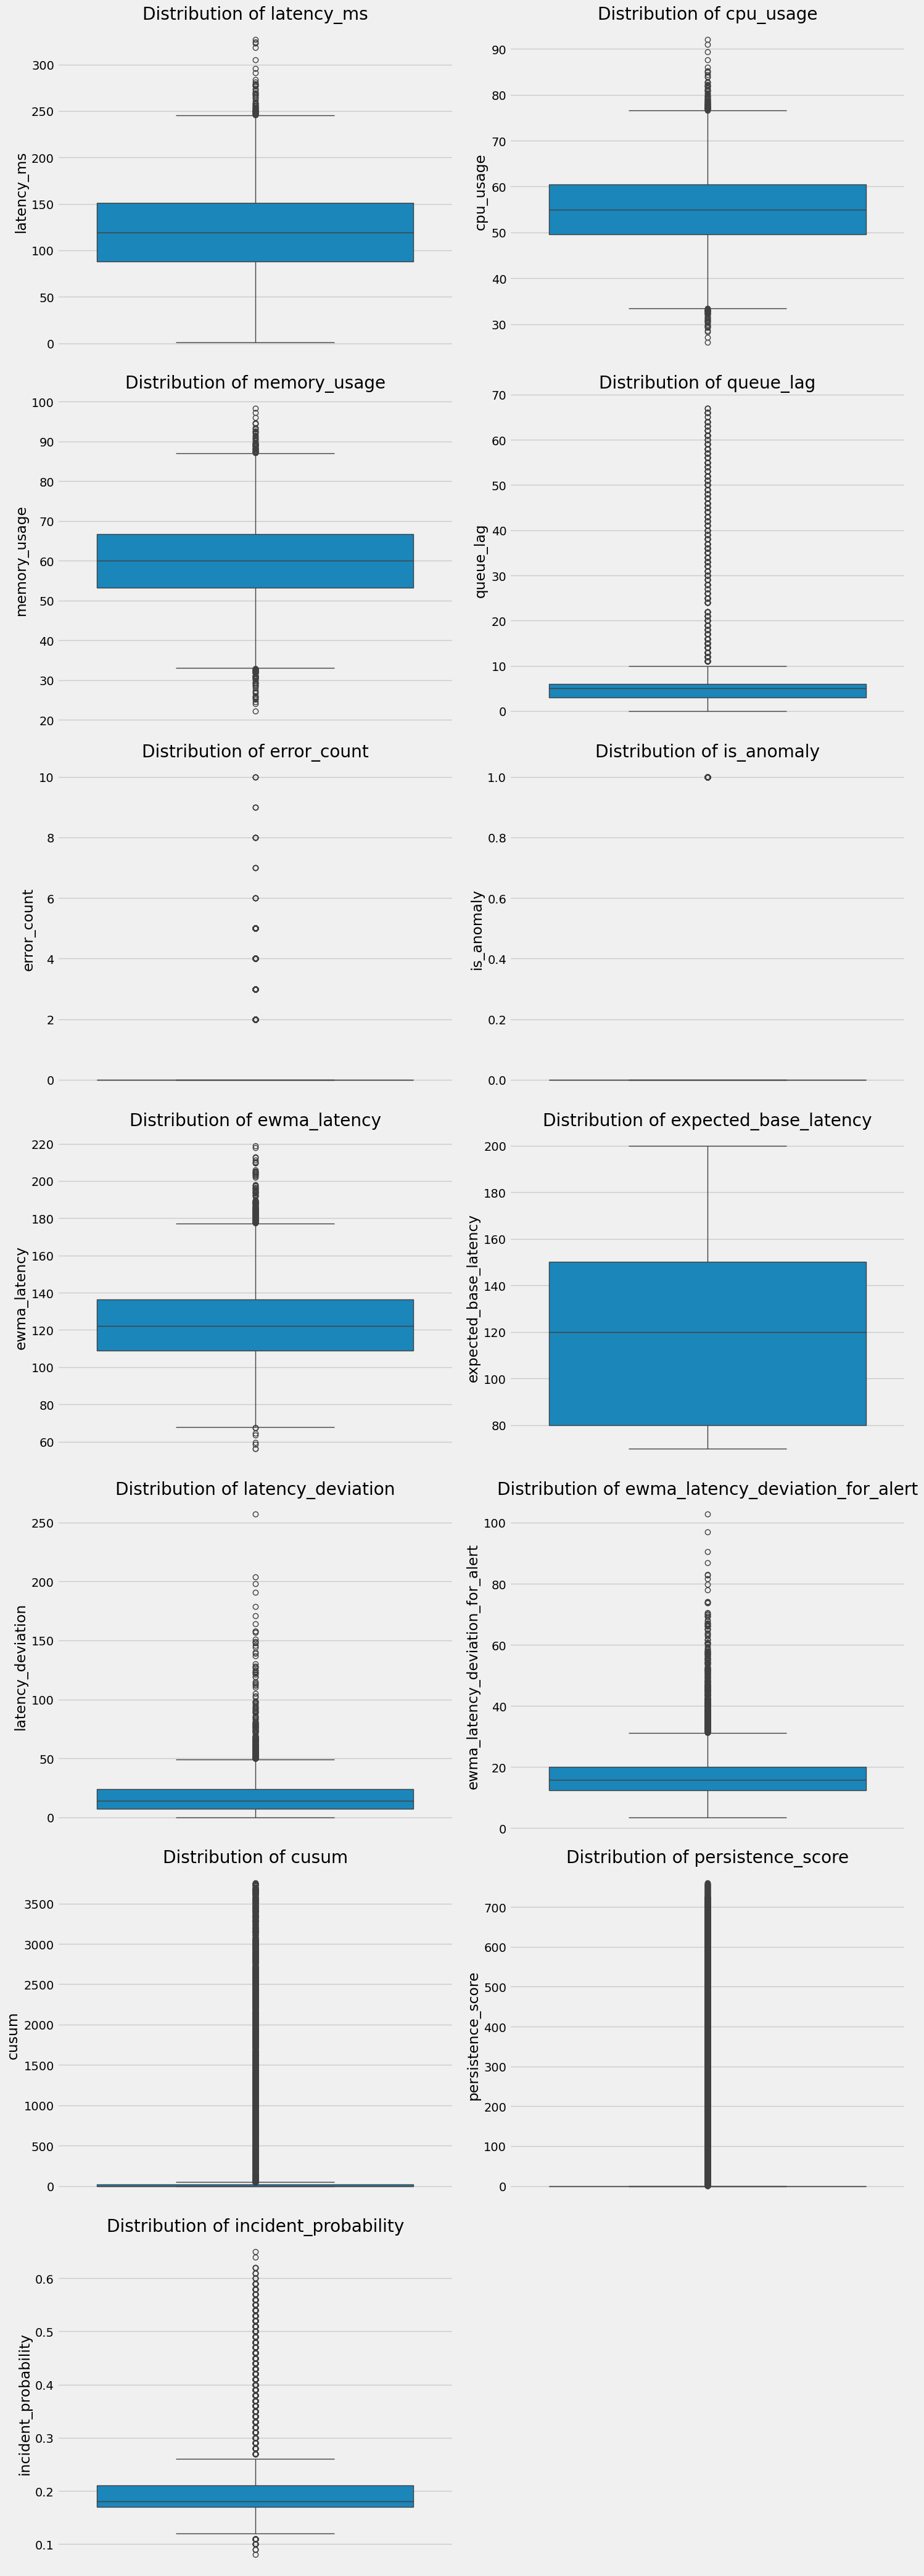

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for all plots in this cell
plt.style.use("fivethirtyeight")

# Assume numerical_columns is defined from a previous cell. If not, re-define it here:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the number of rows and columns for the subplots
num_cols_for_plot = 2 # Number of charts per row
num_rows_for_plot = (len(numerical_columns) + num_cols_for_plot - 1) // num_cols_for_plot

fig, axes = plt.subplots(num_rows_for_plot, num_cols_for_plot, figsize=(15, 6 * num_rows_for_plot))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(numerical_columns):
    # Create the boxplot vertically on the current subplot
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel(col) # Set y-label as it's a vertical boxplot

# Hide any unused subplots if the number of numerical columns is not a perfect multiple of num_cols_for_plot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlap
plt.savefig("visualizations/box_plots_all_numerical.png", bbox_inches="tight")
plt.show()

# Save the entire figure
plt.close() # Closes the plot window to save memory

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression


# Stage 4 KDE Plot for Incident Probability with Thresholds

This plot visualizes the distribution of the `incident_probability` column. Regions where the probability is above 0.5 are highlighted in red, and regions above 0.6 are further highlighted in purple, allowing for quick identification of higher-risk probability ranges.

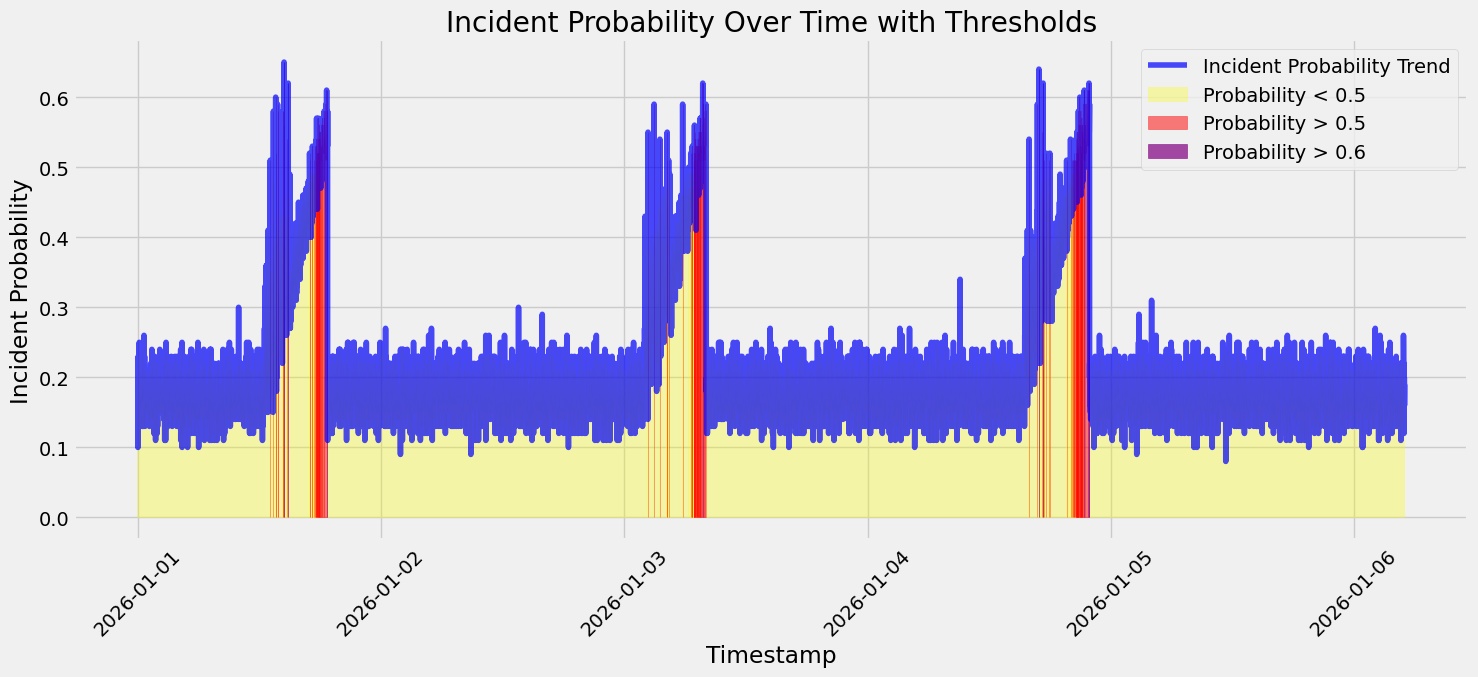

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure timestamp is in datetime format for plotting
df['timestamp'] = pd.to_datetime(df['timestamp'])

plt.figure(figsize=(15, 7))

# Plot the incident probability over time
plt.plot(df['timestamp'], df['incident_probability'], color='blue', label='Incident Probability Trend', alpha=0.7)

# Get data for fill_between
x_values = df['timestamp']
y_values = df['incident_probability']

# Fill the area for incident_probability < 0.5 (yellow)
plt.fill_between(x_values, y_values, where=(y_values < 0.5), color='yellow', alpha=0.3, label='Probability < 0.5')

# Fill the area for incident_probability > 0.5 (red)
plt.fill_between(x_values, y_values, where=(y_values > 0.5), color='red', alpha=0.5, label='Probability > 0.5')

# Fill the area for incident_probability > 0.6 (purple). This will overlap the red in that region.
plt.fill_between(x_values, y_values, where=(y_values > 0.6), color='purple', alpha=0.7, label='Probability > 0.6')

plt.title('Incident Probability Over Time with Thresholds')
plt.xlabel('Timestamp')
plt.ylabel('Incident Probability')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visualizations/incident_probability_time_series.png", bbox_inches="tight")
plt.show()


plt.close() # Close the plot to free up memory

In [17]:
# For categorical columns, we'll fill missing values with the mode (most frequent category)
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(categorical_columns)

Index(['service', 'endpoint', 'region', 'status', 'error_code', 'severity',
       'logdate', 'priority'],
      dtype='str')


# Stage 5 - EDA for categorical columns

In [18]:
"""
df['timestamp'] = pd.to_datetime(df['timestamp'])
# Extract new features from 'timestamp'
df['Transaction_Date'] = df['timestamp'].dt.date
df['Transaction_Time'] = df['timestamp'].dt.time
df['Transaction_Day'] = df['timestamp'].dt.day
df['Transaction_Month'] = df['timestamp'].dt.month
#df['Transaction_Month_Name'] = df['timestamp'].dt.strftime('%b')
df['Transaction_Year'] = df['timestamp'].dt.year
df['Transaction_Hour'] = df['timestamp'].dt.hour
df['Transaction_Minute'] = df['timestamp'].dt.minute
df['Transaction_Second'] = df['timestamp'].dt.second
"""

"\ndf['timestamp'] = pd.to_datetime(df['timestamp'])\n# Extract new features from 'timestamp'\ndf['Transaction_Date'] = df['timestamp'].dt.date\ndf['Transaction_Time'] = df['timestamp'].dt.time\ndf['Transaction_Day'] = df['timestamp'].dt.day\ndf['Transaction_Month'] = df['timestamp'].dt.month\n#df['Transaction_Month_Name'] = df['timestamp'].dt.strftime('%b')\ndf['Transaction_Year'] = df['timestamp'].dt.year\ndf['Transaction_Hour'] = df['timestamp'].dt.hour\ndf['Transaction_Minute'] = df['timestamp'].dt.minute\ndf['Transaction_Second'] = df['timestamp'].dt.second\n"

In [19]:
df['logdate'] = pd.to_datetime(df['timestamp']).dt.date
unique_dates = df['logdate'].unique()
print("Unique Transaction Dates:")
for date in unique_dates:
    print(date)

Unique Transaction Dates:
2026-01-01
2026-01-02
2026-01-03
2026-01-04
2026-01-05
2026-01-06


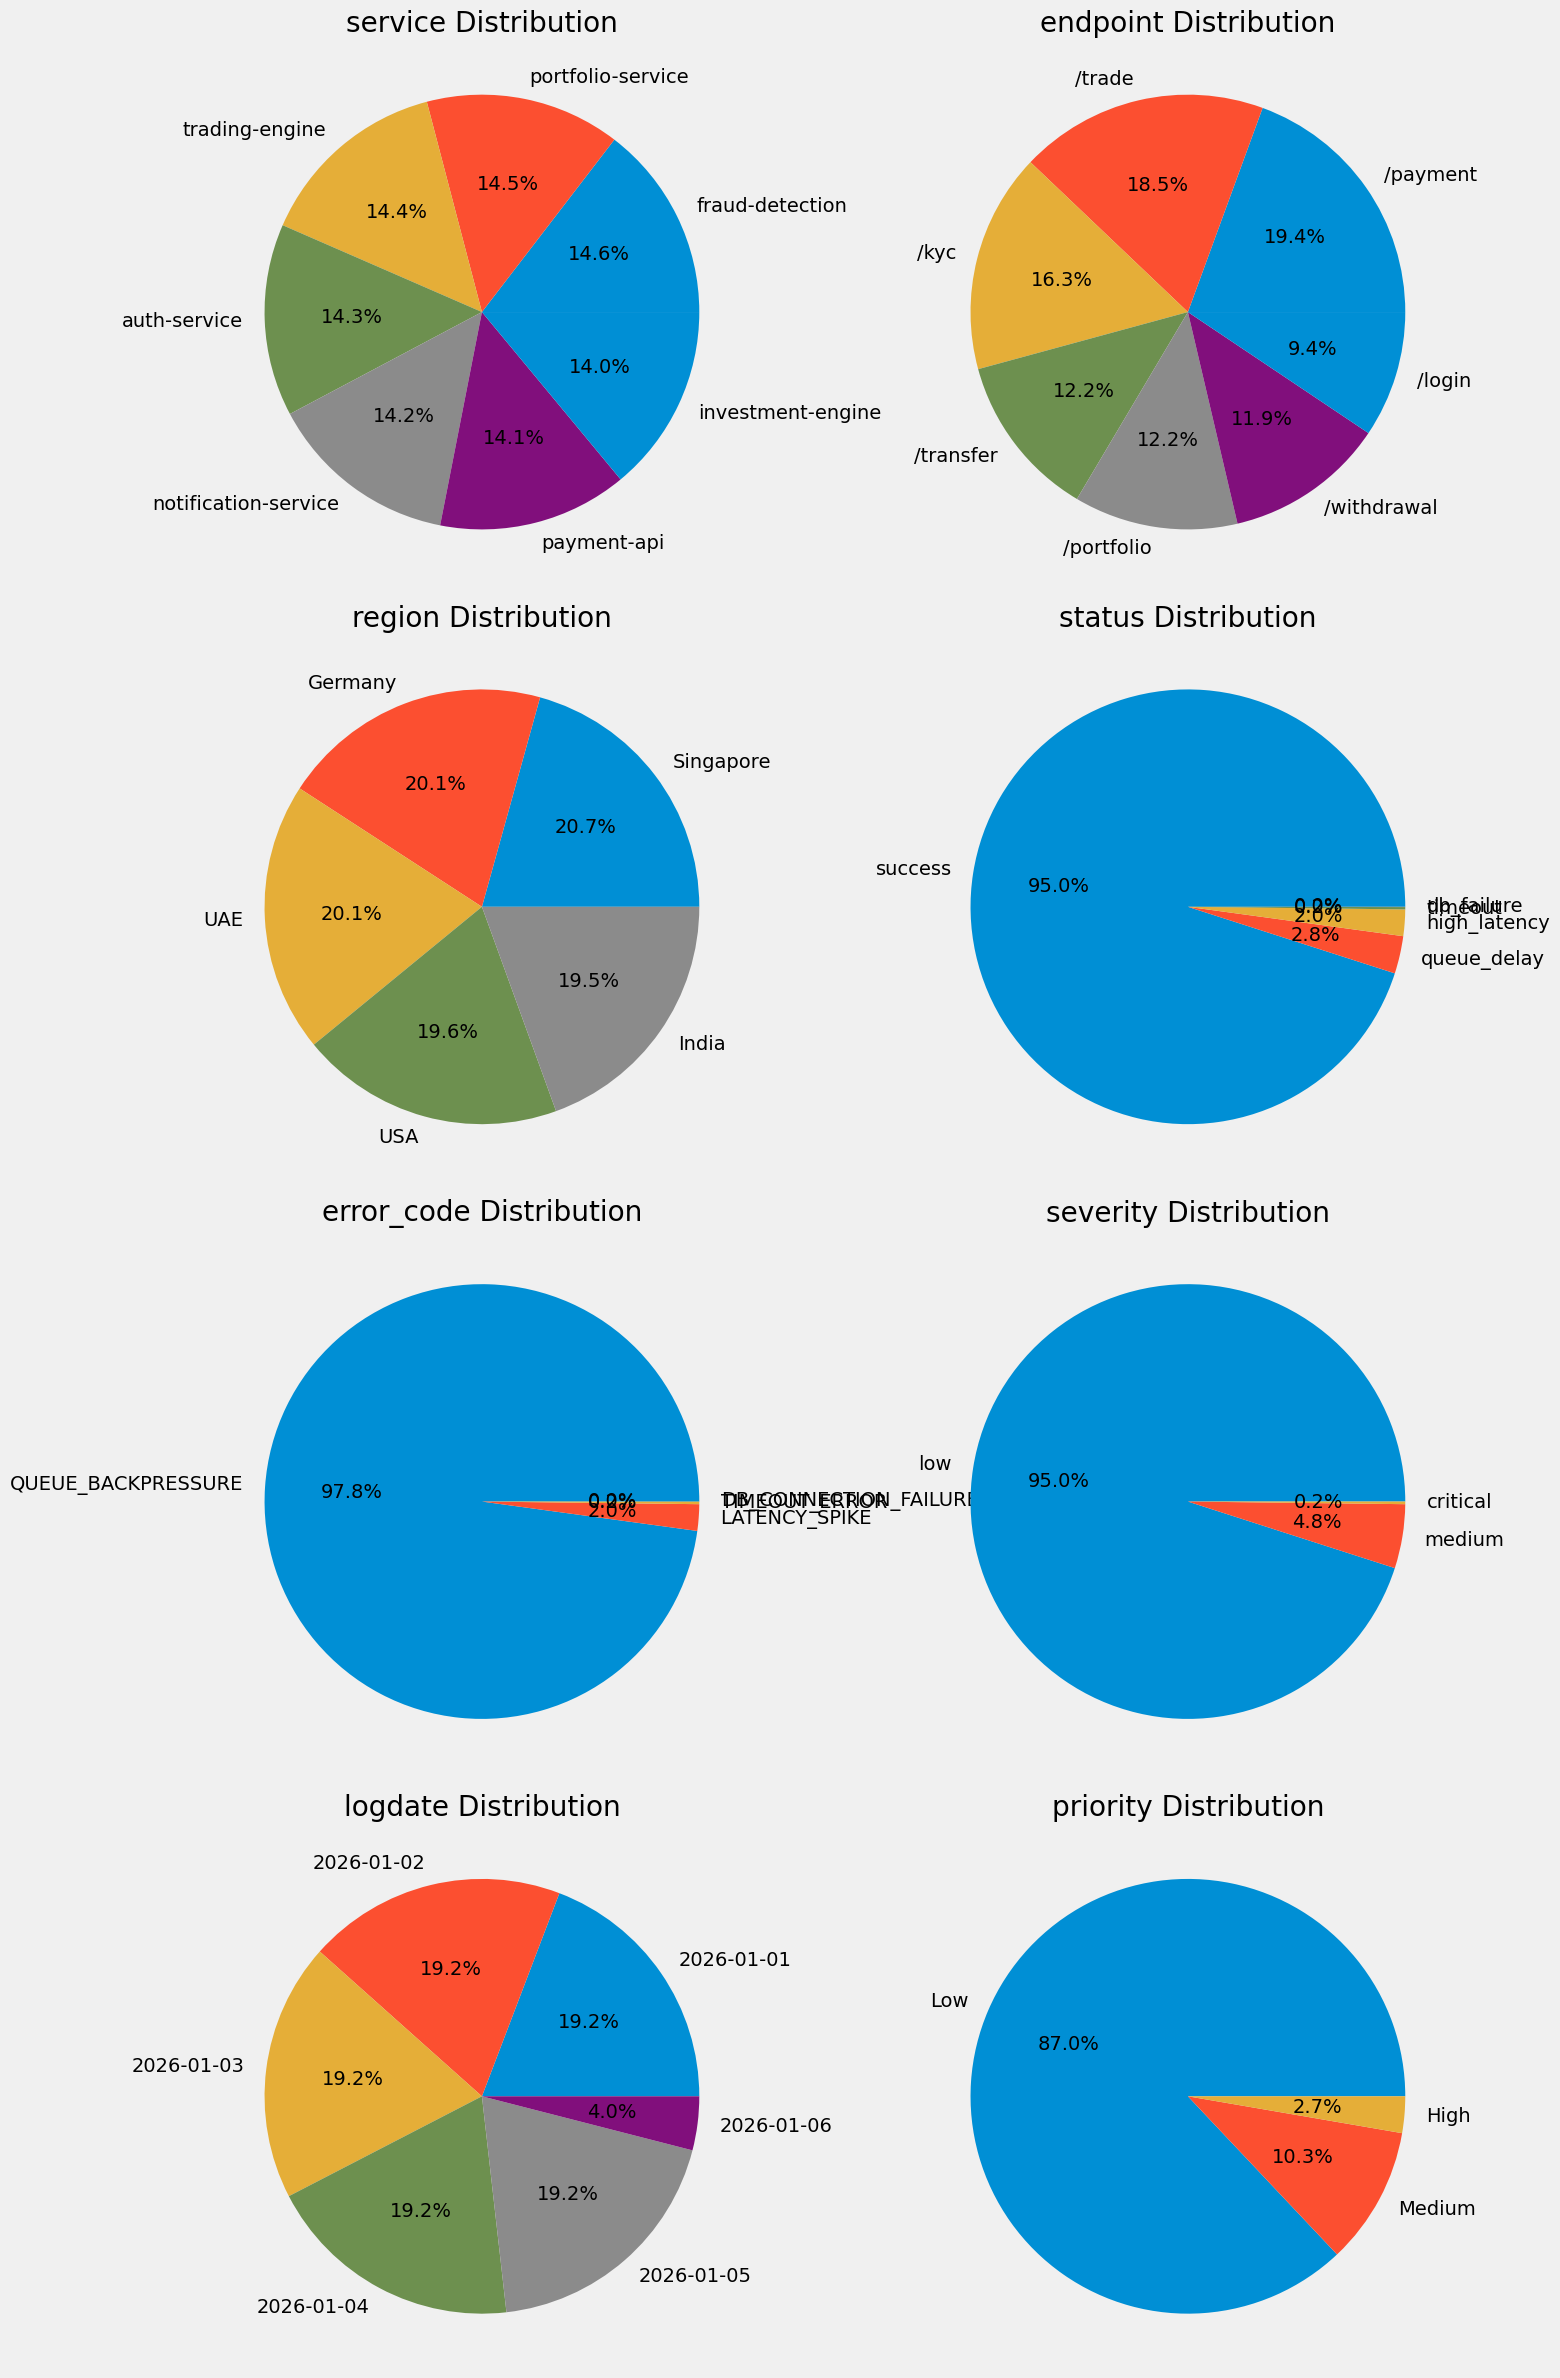

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter categorical columns to include only those with less than 10 unique values
# These are the columns we will actually plot.
plot_categorical_columns = [col for col in categorical_columns if df[col].nunique() < 10]

# Calculate the number of rows needed based on the number of charts to plot
num_cols = 2  # Number of charts per row
num_rows = (len(plot_categorical_columns) + num_cols - 1) // num_cols  # Dynamically calculate rows

# Create the figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 6))  # Adjust figure size for more rows

# Flatten the axes array for easier iteration, handling the case of a single row or column
axes = axes.flatten()

for ax_index, col in enumerate(plot_categorical_columns):
    # Plot on the respective subplot
    ax = axes[ax_index]
    ax.pie(df[col].value_counts(), labels=df[col].unique(), autopct='%1.1f%%')
    ax.set_title(f'{col} Distribution')

# Hide any unused subplots (in case there are fewer than `num_rows * num_cols` charts)
for i in range(len(plot_categorical_columns), len(axes)):
    axes[i].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

# Stage 6 - Encode Categorical Features

In [21]:
# Initializing the LabelEncoder
#Preprocessing data before machine learning, To map text strings to integers like Red- 0, Blue - 1

label_encoder = LabelEncoder()

In [22]:
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [23]:
df.head()

,timestamp,service,endpoint,region,latency_ms,cpu_usage,memory_usage,queue_lag,status,error_code,...,latency_deviation,ewma_latency_deviation_for_alert,ewma_alert,logdate,cusum,cusum_alert,combined_alert,persistence_score,incident_probability,priority
0,2026-01-01 00:00:00,1,2,2,206,56.66,71.97,7,3,2,...,6,6.00,False,0,0.00,False,False,0,0.18,1
1,2026-01-01 00:00:30,5,4,2,122,59.93,55.26,4,3,2,...,2,3.65,False,0,0.00,False,False,0,0.20,1
2,2026-01-01 00:01:00,6,2,0,108,32.20,46.85,2,3,2,...,8,5.63,False,0,0.00,False,False,0,0.10,1
3,2026-01-01 00:01:30,0,0,3,93,51.07,40.44,1,3,2,...,13,8.54,False,0,0.00,False,False,0,0.17,1
4,2026-01-01 00:02:00,6,5,0,134,54.29,60.76,2,3,2,...,34,17.72,False,0,10.68,False,False,0,0.18,1


In [24]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   timestamp                         15000 non-null  datetime64[us]
 1   service                           15000 non-null  int64         
 2   endpoint                          15000 non-null  int64         
 3   region                            15000 non-null  int64         
 4   latency_ms                        15000 non-null  int64         
 5   cpu_usage                         15000 non-null  float64       
 6   memory_usage                      15000 non-null  float64       
 7   queue_lag                         15000 non-null  int64         
 8   status                            15000 non-null  int64         
 9   error_code                        15000 non-null  int64         
 10  severity                          15000 non-null  int64  

In [25]:
df.nunique()

timestamp                           15000
service                                 7
endpoint                                7
region                                  5
latency_ms                            270
cpu_usage                            3563
memory_usage                         4175
queue_lag                              67
status                                  5
error_code                              4
severity                                3
error_count                            10
is_anomaly                              2
ewma_latency                         6757
expected_base_latency                   7
latency_deviation                     129
ewma_latency_deviation_for_alert     2848
ewma_alert                              2
logdate                                 6
cusum                                3008
cusum_alert                             2
combined_alert                          2
persistence_score                     761
incident_probability              

Stage 6 EDA after Label Encoder

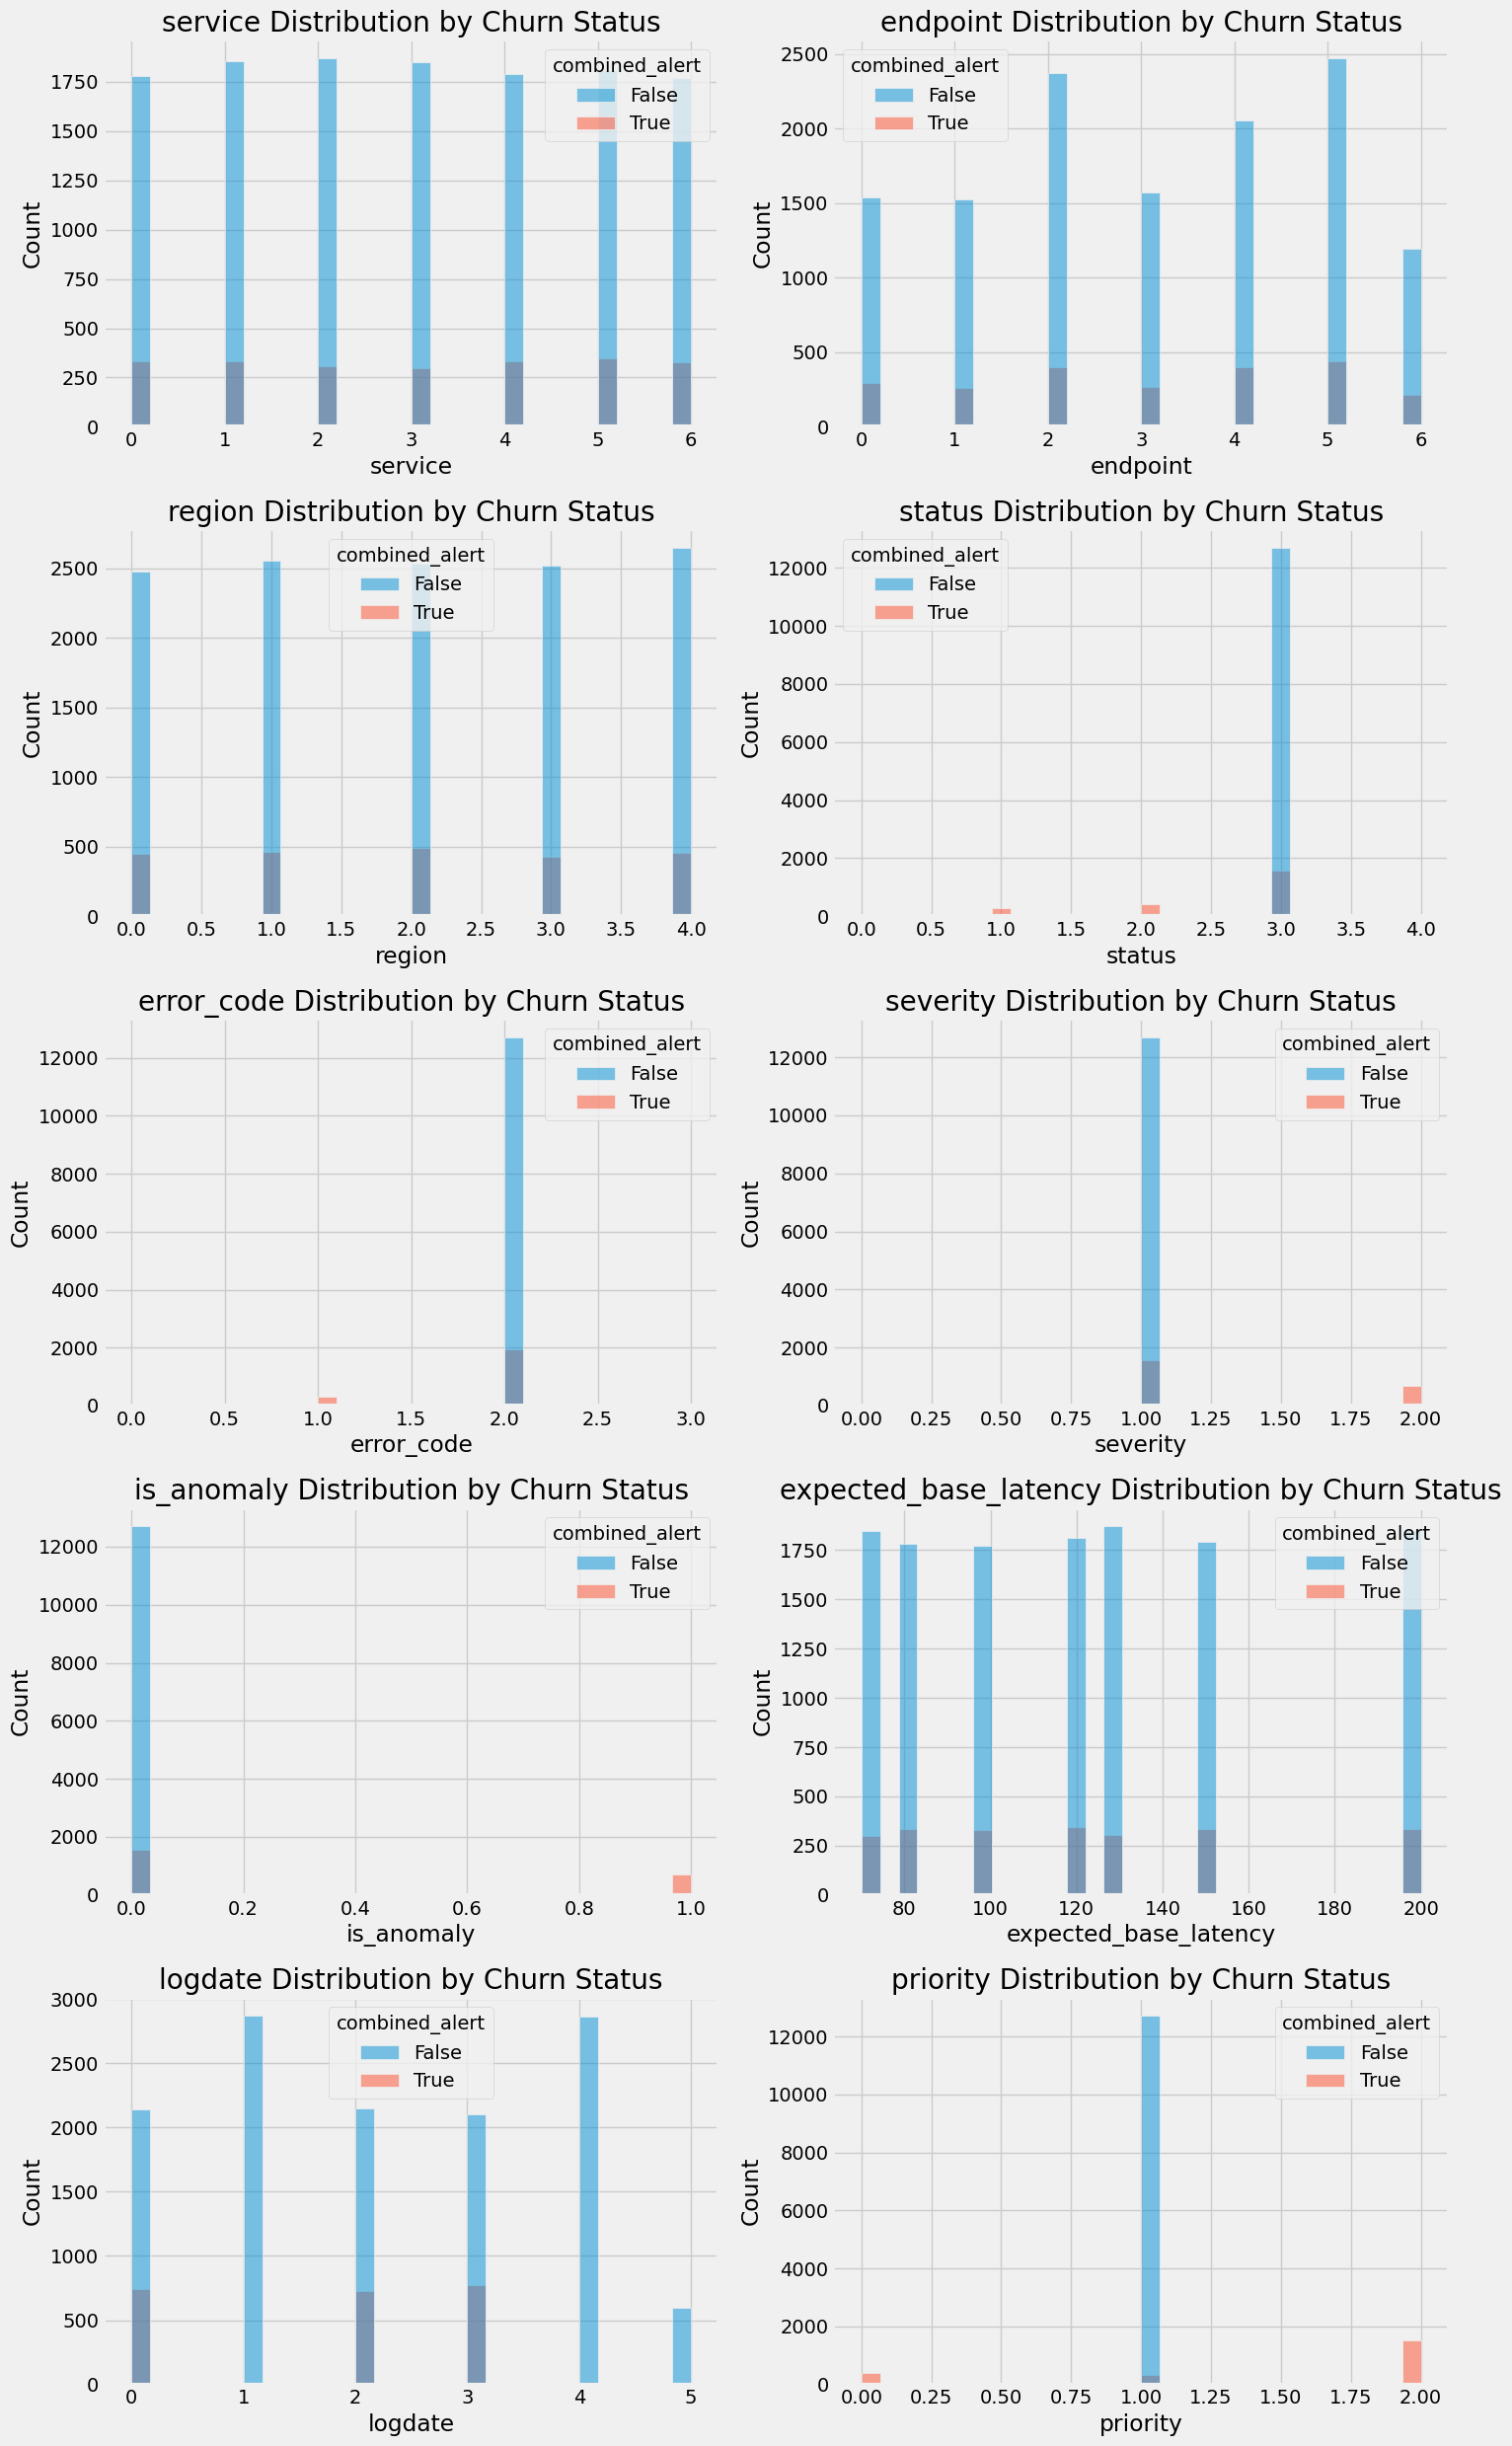

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter numerical columns with less than 10 unique values
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
numerical_features = [col for col in numerical_features if df[col].nunique() < 10]

# Set the number of charts per row
num_cols = 2  # Number of charts per row

# Calculate the number of rows needed based on the number of features
num_rows = (len(numerical_features) + num_cols - 1) // num_cols  # This ensures enough rows are created

# Create a figure with the appropriate number of rows and columns
plt.figure(figsize=(15, 5 * num_rows))

# Plot the histograms for the filtered numerical columns
for i, feature in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(data=df, x=feature, hue='combined_alert', bins=30)
    plt.title(f'{feature} Distribution by Churn Status')

plt.tight_layout()
plt.show()

# **Stage 7 - Visualize Fraud Patterns and Distribution of Features**

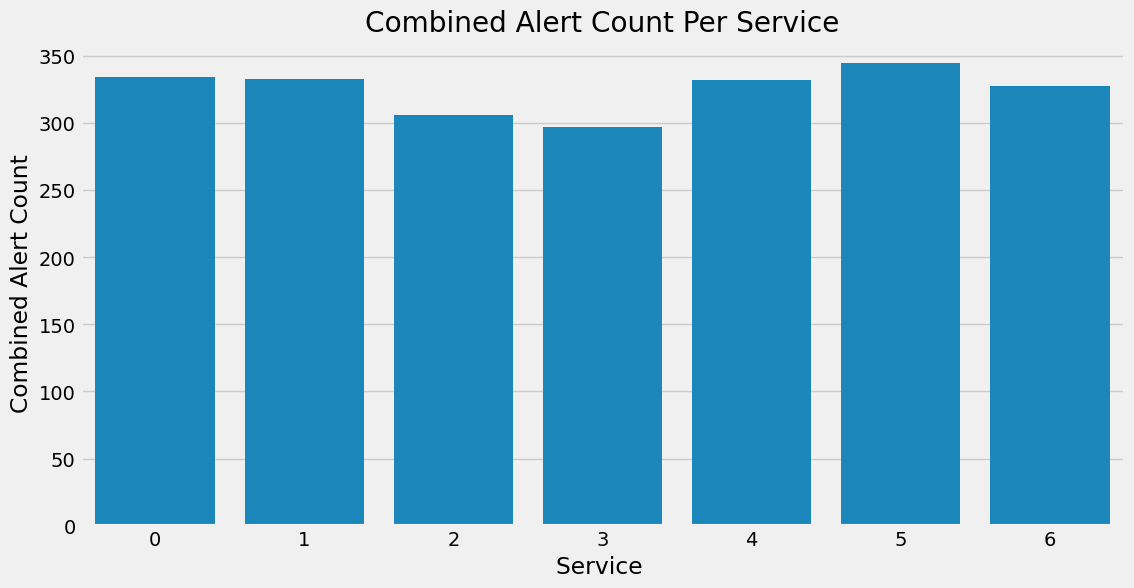

In [27]:
#Visualize Alert Vs Service
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
alert_counts_per_service = df.groupby('service')['combined_alert'].sum().reset_index()
sns.barplot(data=alert_counts_per_service, x='service', y='combined_alert')
plt.title("Combined Alert Count Per Service")
plt.xlabel("Service ")
plt.ylabel("Combined Alert Count")
plt.show()

# Stage 8 - Plot Correlation Matrix to Understand Feature Relationships

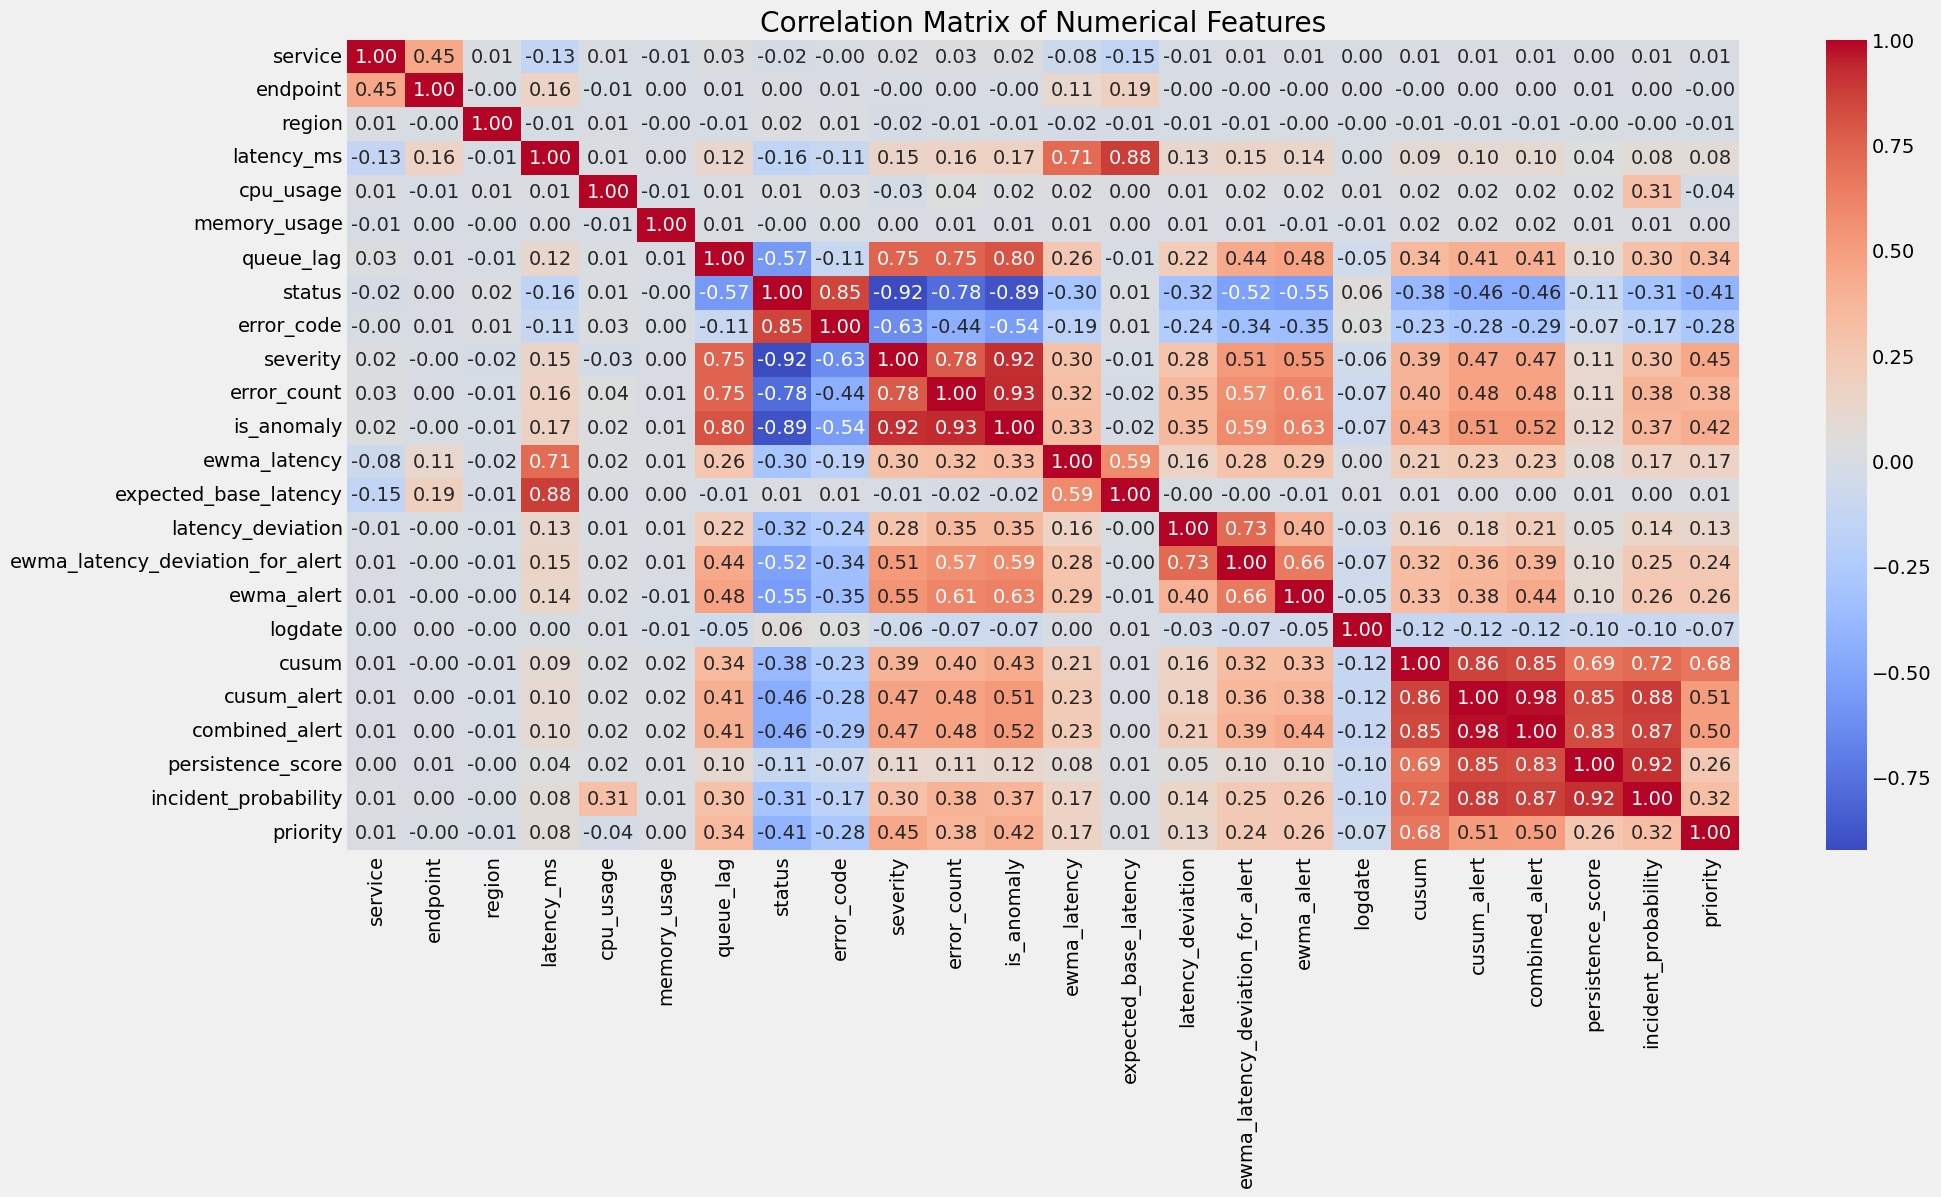

In [28]:
plt.figure(figsize=(20, 10))

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['number', 'bool'])

# Exclude any other non-numeric columns that might have slipped through (like encoded datetime objects if not handled)
# For instance, 'timestamp' was converted to int64 by LabelEncoder, but original datetime objects are not numerical.
# Let's ensure that any columns that are clearly not meant for correlation are excluded.
# Based on df.info(), the original timestamp, Transaction_Date, Transaction_Time columns are either object or int64 after encoding.
# If 'timestamp' was label encoded, it becomes int64, which is technically numeric but semantically not for correlation.
# So, let's explicitly drop it if it's there, along with the extracted date/time features.

# If 'timestamp' was label encoded to int64, it might still not be meaningful for correlation. Let's drop it explicitly.
columns_to_exclude = ['timestamp', 'Transaction_Date', 'Transaction_Time']
for col in columns_to_exclude:
    if col in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=[col])

correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.savefig("visualizations/correlation_matrix.png") # Save before showing/closing
plt.show()
plt.close()

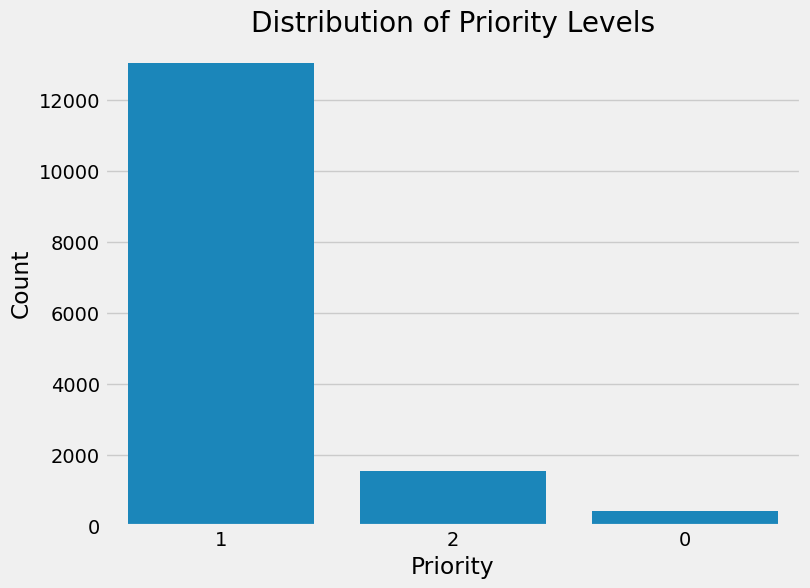

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='priority', data=df, order=df['priority'].value_counts().index)
plt.title('Distribution of Priority Levels')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.savefig('visualizations/priority_distribution.png')
plt.show()
plt.close()

# **Stage 9 : Applying Isolation Forest for Anomaly Detection (Raw Data, no statistical features included)**

This section applies the Isolation Forest algorithm, an unsupervised learning method, to detect anomalies in the banking logs. Isolation Forest works by isolating anomalies rather than profiling normal data points, which makes it efficient and effective for high-dimensional datasets. The model will identify data points that are 'different' from the majority, flagging them as potential anomalies.

In [30]:
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler

print("Applying Isolation Forest Detection...\n")

# Define numerical features for Isolation Forest
# Exclude 'timestamp' and other non-numerical or target-related columns
features_for_isolation_forest = df[[
    "service", "latency_ms", "cpu_usage",
    "queue_lag", "error_count"
]].copy()
robust_scaler = RobustScaler()
le = LabelEncoder()
features_for_isolation_forest['service'] = le.fit_transform(features_for_isolation_forest['service'])
# 2. Build a Pipeline combining the RobustScaler and Isolation Forest
# This automatically scales the data right before passing it to the model
iso_forest_pipeline = make_pipeline(
    robust_scaler, IsolationForest(contamination=0.05, random_state=42)
)


# 3. Fit the pipeline and predict anomalies
# Isolation Forest returns: 1 for normal data, -1 for outliers
df["anomaly_score"] = iso_forest_pipeline.fit_predict(features_for_isolation_forest)

print("Isolation Forest detection completed.")

# The commented section used different feature selection and was already structured
# for direct use. I will now integrate the prediction result.
# The 'predictions' variable is not used in the pipeline approach, so I will remove the old commented block.

# Add Isolation Forest anomaly predictions to the DataFrame
# 'anomaly_score' from pipeline already has 1 for normal and -1 for outlier
df['ml_anomaly'] = df['anomaly_score'].apply(lambda x: 1 if x == -1 else 0)

# Save outputs
df.to_csv("outputs/sentineliq_results_ml_isofor.csv",index=False )

print("Output with metrics saved to outputs/sentineliq_results_ml_isofor.csv ")

print("Isolation Forest detection completed.\n")

Applying Isolation Forest Detection...

Isolation Forest detection completed.
Output with metrics saved to outputs/sentineliq_results_ml_isofor.csv 
Isolation Forest detection completed.



In [31]:
# Create models directory if it doesn't exist
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save the trained pipeline
model_path = os.path.join(models_dir, 'Isolation_forest_RawData.joblib')
joblib.dump(iso_forest_pipeline, model_path)
# Save the trained instance to disk!
model_path = os.path.join(models_dir, 'robust_scaler.pkl')
joblib.dump(robust_scaler, model_path)
model_path = os.path.join(models_dir, 'label_encoder.pkl')
joblib.dump(le, model_path)
print(f"Trained Isolation Forest pipeline saved to: {model_path}")

Trained Isolation Forest pipeline saved to: models\label_encoder.pkl


**Inspecting Isolation Forest Results**

Let's examine the first few rows of the DataFrame with the new ml_anomaly column and get a count of the detected anomalies. This will give us an initial idea of how many data points the Isolation Forest algorithm has identified as anomalous.


In [32]:
#print(df[['timestamp', 'latency_ms', 'cpu_usage', 'memory_usage', 'queue_lag', 'ml_anomaly']].head())
print(f"Total anomalies detected by Isolation Forest: {df['ml_anomaly'].sum()}")



Total anomalies detected by Isolation Forest: 750


### Isolation Forest Model Evaluation

Now that we have applied the Isolation Forest, let's evaluate its performance using key classification metrics. We will compare the model's predictions (`ml_anomaly`) against the true anomaly labels (`is_anomaly`) present in the dataset.

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Prepare true labels and predicted labels
y_true = df['is_anomaly']
y_pred = df['ml_anomaly']

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_true, y_pred))

# Calculate ROC AUC score if both classes are present
if len(y_true.unique()) > 1:
    roc_auc = roc_auc_score(y_true, y_pred)
    print(f"\n--- ROC AUC Score: {roc_auc:.4f} ---")
else:
    print("\nROC AUC Score cannot be calculated as only one class is present in y_true.")


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14257
           1       0.95      0.96      0.95       743

    accuracy                           1.00     15000
   macro avg       0.97      0.98      0.97     15000
weighted avg       1.00      1.00      1.00     15000


--- Confusion Matrix ---
[[14218    39]
 [   32   711]]

--- ROC AUC Score: 0.9771 ---


# Metric	Meaning
Precision	- Of detected anomalies, how many were truly anomalous

Recall- How many true anomalies were found

F1-score- Balance of precision + recall

ROC-AUC	- Ranking quality

Confusion Matrix -	TP, FP, FN, TN

Model working pretty well with given performance

--- Classification Report ---Contamination 0.25
              precision    recall  f1-score   support

           0       1.00      0.79      0.88     14276
           1       0.19      1.00      0.32       724

    accuracy                           0.80     15000
   macro avg       0.60      0.89      0.60     15000
weighted avg       0.96      0.80      0.85     15000


--- Confusion Matrix ---
[[11250  3026]
 [    0   724]]

--- ROC AUC Score: 0.8940 ---

--- Classification Report ---(Contamination : 0.15)
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     14276
           1       0.32      1.00      0.49       724

    accuracy                           0.90     15000
   macro avg       0.66      0.95      0.72     15000
weighted avg       0.97      0.90      0.92     15000


--- Confusion Matrix ---
[[12750  1526]
 [    0   724]]

--- ROC AUC Score: 0.9466 ---


--- Classification Report ---(Contamination: 0.05)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14276
           1       0.94      0.98      0.96       724

    accuracy                           1.00     15000
   macro avg       0.97      0.99      0.98     15000
weighted avg       1.00      1.00      1.00     15000


--- Confusion Matrix ---
[[14232    44]
 [   18   706]]

--- ROC AUC Score: 0.9860 ---


In [34]:

df.sort_values("anomaly_score").head(500)

,timestamp,service,endpoint,region,latency_ms,cpu_usage,memory_usage,queue_lag,status,error_code,...,ewma_alert,logdate,cusum,cusum_alert,combined_alert,persistence_score,incident_probability,priority,anomaly_score,ml_anomaly
1535,2026-01-01 12:47:30,0,1,0,137,57.79,59.60,14,1,1,...,True,0,446.68,True,True,13,0.29,1,-1,1
1534,2026-01-01 12:47:00,2,4,0,160,46.74,50.64,11,1,1,...,True,0,413.00,True,True,12,0.28,1,-1,1
1532,2026-01-01 12:46:00,4,6,1,248,54.23,68.11,10,1,1,...,True,0,425.64,True,True,10,0.27,1,-1,1
1529,2026-01-01 12:44:30,1,0,4,230,47.62,56.91,20,1,1,...,True,0,374.60,True,True,7,0.28,1,-1,1
1527,2026-01-01 12:43:30,4,6,4,170,64.87,75.04,48,2,2,...,True,0,366.24,True,True,5,0.36,2,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6017,2026-01-03 02:08:30,4,2,0,170,58.53,67.87,59,2,2,...,False,2,269.20,True,True,12,0.26,1,-1,1
4120,2026-01-02 10:20:00,1,5,4,214,78.75,52.04,2,3,2,...,False,1,2.36,False,False,0,0.26,1,-1,1
4159,2026-01-02 10:39:30,1,0,2,225,80.21,74.06,1,3,2,...,False,1,3.40,False,False,0,0.26,1,-1,1
4508,2026-01-02 13:34:00,3,2,1,90,72.13,76.83,26,2,2,...,False,1,0.00,False,False,0,0.30,1,-1,1


# **Stage 10 : Comparing models on Rolling Window with Statistical Features**

**Step** 1: Window-Based Feature Engineering

**Load Libraries**

In [35]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [36]:
Data_Config = {
    "window_size": "5min",
    "traindata": 0.8
}
ENSEMBLE_CONFIG = {

    "weights": {
        "IsolationForest": 0.8,
        "LOF": 0.0,
        "OneClassSVM": 0.2
    },

    "threshold": 0.7
}

print(f"Ensemble Weights: {ENSEMBLE_CONFIG['weights']}")
print(f"Ensemble Threshold: {ENSEMBLE_CONFIG['threshold']}")
print(f"IsolationForest Weight: {ENSEMBLE_CONFIG['weights']['IsolationForest']}")

Ensemble Weights: {'IsolationForest': 0.8, 'LOF': 0.0, 'OneClassSVM': 0.2}
Ensemble Threshold: 0.7
IsolationForest Weight: 0.8


**1. Creating 5 min rolling window and aggregate raw data**

In [37]:
df = pd.read_csv("outputs/sentineliq_results.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

window_df = (
    df.set_index("timestamp")
      .resample(Data_Config["window_size"])
      .agg({
          "latency_ms": ["mean", "max", "std"],
          "cpu_usage": ["mean", "max"],
          "memory_usage": ["mean"],
          "queue_lag": ["mean", "max"],
          "error_count": ["sum"],
          "incident_probability": ["mean"],
          "cusum": ["max"],
          "persistence_score": ["mean"],
          "is_anomaly": "max"
      })
)

window_df.columns = [
    "_".join(col)
    for col in window_df.columns
]
window_df = window_df.reset_index()
window_df = window_df.fillna(0)

**2**. Feature Selection

In [38]:
feature_cols = [
    "latency_ms_mean",
    "latency_ms_max",
    "latency_ms_std",
    "cpu_usage_mean",
    "cpu_usage_max",
    "memory_usage_mean",
    "queue_lag_mean",
    "queue_lag_max",
    "error_count_sum",
    "incident_probability_mean",
    "cusum_max",
    "persistence_score_mean"
]


In [39]:
import numpy as np

skewed_cols = [
    "latency_ms_max",
    "error_count_sum",
    "cusum_max"
]

for col in skewed_cols:
    window_df[col] = np.log1p(window_df[col])

**3**. Train terst Split

In [40]:
split_idx = int(len(window_df) * Data_Config["traindata"])

train_df = window_df.iloc[:split_idx]
test_df = window_df.iloc[split_idx:]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_test = test_df["is_anomaly_max"]

In [41]:
print(f"Shape of y test: {y_test.shape}")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of y test: (300,)
Shape of X_train: (1200, 12)
Shape of X_test: (300, 12)


**4.** Scaling

In [42]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



**5.** Create Model registry

Unified model registry

In [43]:
models = {
    "IsolationForest": IsolationForest(
        n_estimators=300,
        contamination=0.03,
        random_state=42
    ),

    "LOF": LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.03,
        novelty=True
    ),

    "OneClassSVM": OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=0.03
    )
}

6. Unified Evaluation function

In [44]:
def evaluate_model(name, y_true, y_pred, scores):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    roc_auc = roc_auc_score(y_true, scores)

    pr_auc = average_precision_score(y_true, scores)

    return {
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "ROC_AUC": round(roc_auc, 4),
        "PR_AUC": round(pr_auc, 4)
       }

7. Unified pipeline - Creating unified prediction and Evaluation pipeline

In [45]:
results = []

all_scores = {}

for name, model in models.items():

    print(f"Training {name}...")

    # Train
    model.fit(X_train_scaled)

    # Predict
    preds = model.predict(X_test_scaled)

    # Convert labels
    preds = np.where(preds == -1, 1, 0)
    if name=='LOF':
        scores = model.decision_function(X_test_scaled)
    else:
    # Get anomaly scores
      scores = -model.decision_function(X_test_scaled) #Default Behavior of sklearn Anomaly Models :
                                                     #higher score = more normal else anomolous
                                                     # but for ensemble model we want reverse : higher score = more anomalous

    # Save scores
    all_scores[name] = scores

    # Evaluate
    result = evaluate_model(
        name,
        y_test,
        preds,
        scores
    )

    results.append(result)

Training IsolationForest...
Training LOF...
Training OneClassSVM...


In [46]:
print(f"Shape of y test: {y_test.shape}")
print(f"Number of models in all_scores: {len(all_scores)}")
print(all_scores.values().__len__())
print(f"Shape of all_scores['IsolationForest']: {all_scores['IsolationForest'].shape}")
print(f"Shape of all_scores['LOF']: {all_scores['LOF'].shape}")
print(f"Shape of all_scores['OneClassSVM']: {all_scores['OneClassSVM'].shape}")

Shape of y test: (300,)
Number of models in all_scores: 3
3
Shape of all_scores['IsolationForest']: (300,)
Shape of all_scores['LOF']: (300,)
Shape of all_scores['OneClassSVM']: (300,)


8. Creating comparision Table for all three models

In [47]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="PR_AUC",
    ascending=False
)

print(results_df)

             Model  Precision  Recall      F1  ROC_AUC  PR_AUC
0  IsolationForest      0.000     0.0  0.0000      1.0  1.0000
2      OneClassSVM      0.500     1.0  0.6667      1.0  1.0000
1              LOF      0.125     1.0  0.2222      0.0  0.0033


9. Build Ensemble Layer

# Stage 11: Ensemble Layer with All Three Models (Rolling Window)

### How the Anomaly Detection Models are Combined into an Ensemble

The ensemble layer combines the anomaly scores from individual models (Isolation Forest, LOF, and One-Class SVM) to produce a more robust and comprehensive anomaly detection signal. This is done in three main steps:

1.  **Normalize Individual Anomaly Scores:**
    *   Each anomaly detection model outputs a score indicating how anomalous a data point is. To combine these scores effectively, they first need to be normalized to a common scale (e.g., 0 to 1). This ensures that models with different scoring ranges contribute fairly to the ensemble.
    *   The `MinMaxScaler` from `sklearn.preprocessing` is used for this purpose. It scales each model's raw anomaly scores to a range between 0 and 1.

2.  **Combine Normalized Scores with Weighted Averages:**
    *   After normalization, the scores from each model are combined using a weighted average. The weights for each model are defined in the `ENSEMBLE_CONFIG` dictionary. This allows prioritizing the contributions of models that are known to perform better (e.g., Isolation Forest, which was identified as a strong performer).
    *   The `ENSEMBLE_CONFIG['weights']` specifies the importance of each model in the final ensemble score. For instance, `IsolationForest` has a weight of `0.8` and `OneClassSVM` has `0.2`, while `LOF` has `0.0`, meaning its contribution is currently ignored in the weighted average.

3.  **Apply a Threshold for Final Anomaly Prediction:**
    *   A global threshold, also defined in `ENSEMBLE_CONFIG['threshold']`, is applied to the `ensemble_score`. Any data point with an `ensemble_score` greater than this threshold is classified as an anomaly (`1`), otherwise it is considered normal (`0`).


This ensemble approach leverages the strengths of multiple models, and with proper weighting and thresholding, it can provide a more robust and accurate anomaly detection system than any single model alone.

### Build Ensemble Layer

In [48]:
# Normalize Score
from sklearn.preprocessing import MinMaxScaler

score_scaler = MinMaxScaler()

normalized_scores = {}

for name, scores in all_scores.items():

    normalized_scores[name] = (
        score_scaler
        .fit_transform(scores.reshape(-1, 1))
        .flatten()
    )


In [49]:
print(f"Shape of normalized_scores['IsolationForest']: {normalized_scores['IsolationForest'].shape}")
print(f"Shape of normalized_scores['LOF']: {normalized_scores['LOF'].shape }")
print(f"Shape of normalized_scores['OneClassSVM']: {normalized_scores['OneClassSVM'].shape}")

print(type(normalized_scores["IsolationForest"][0]))
print(type(normalized_scores["LOF"][0]))
print(type(normalized_scores["OneClassSVM"][0]))

Shape of normalized_scores['IsolationForest']: (300,)
Shape of normalized_scores['LOF']: (300,)
Shape of normalized_scores['OneClassSVM']: (300,)
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>


In [50]:
for name in normalized_scores:

    normalized_scores[name] = np.asarray(
        normalized_scores[name],
        dtype=np.float64
    ).ravel()


In [51]:
# Calculate Ensemble Risk score and final prediction
ensemble_score = (
    (ENSEMBLE_CONFIG['weights']['IsolationForest']) * normalized_scores["IsolationForest"] +
    (ENSEMBLE_CONFIG['weights']['LOF']) * normalized_scores["LOF"] +
    (ENSEMBLE_CONFIG['weights']['OneClassSVM']) * normalized_scores["OneClassSVM"]
)
ensemble_preds = (
    ensemble_score > ENSEMBLE_CONFIG['threshold']
).astype(int)


In [52]:
print(f"Shape of ensemble_score: {ensemble_score.shape}")
print(f"Shape of ensemble_preds: {ensemble_preds.shape}")

Shape of ensemble_score: (300,)
Shape of ensemble_preds: (300,)


### Evaluate Ensemble

In [53]:
print(f"Shape of test_df['is_anomaly_max']: {test_df['is_anomaly_max'].shape}")
print(f"Shape of ensemble_preds: {ensemble_preds.shape}")
print(f"Shape of y test: {y_test.shape}")


Shape of test_df['is_anomaly_max']: (300,)
Shape of ensemble_preds: (300,)
Shape of y test: (300,)


In [54]:
ensemble_result = evaluate_model(
     "Ensemble",
     y_test,
     ensemble_preds,
     ensemble_score
  )

print(ensemble_result)

{'Model': 'Ensemble', 'Precision': 0.1667, 'Recall': 1.0, 'F1': 0.2857, 'ROC_AUC': 1.0, 'PR_AUC': 1.0}


In [55]:
print("Min:", ensemble_score.min())
print("Max:", ensemble_score.max())

print(
    "95 percentile:",
    np.percentile(ensemble_score, 95)
)

print(
    "97 percentile:",
    np.percentile(ensemble_score, 97)
)

print(
    "99 percentile:",
    np.percentile(ensemble_score, 99)
)

Min: 0.09858770178673143
Max: 1.0
95 percentile: 0.5921427619805635
97 percentile: 0.6388048152429903
99 percentile: 0.7640457491743248


In [56]:
top_k = int(len(ensemble_score) * 0.01)

top_indices = np.argsort(
    ensemble_score
)[-top_k:]

top_k_precision = (
    y_test.iloc[top_indices]
    .sum() / top_k
)

print(top_k_precision)

0.3333333333333333


### ROC and Precision-Recall Curves for Ensemble Model

To further evaluate the ensemble model's performance and understand its trade-offs between different metrics, we can visualize the Receiver Operating Characteristic (ROC) curve and the Precision-Recall (PR) curve.

*   **ROC Curve**: Plots the True Positive Rate (Recall) against the False Positive Rate at various threshold settings. A higher area under the curve (AUC-ROC) indicates a better ability to distinguish between anomalous and normal instances.

*   **Precision-Recall Curve**: Plots Precision against Recall at various threshold settings. This curve is particularly informative for imbalanced datasets, where a high AUC-PR indicates good performance in identifying positive classes while minimizing false positives.

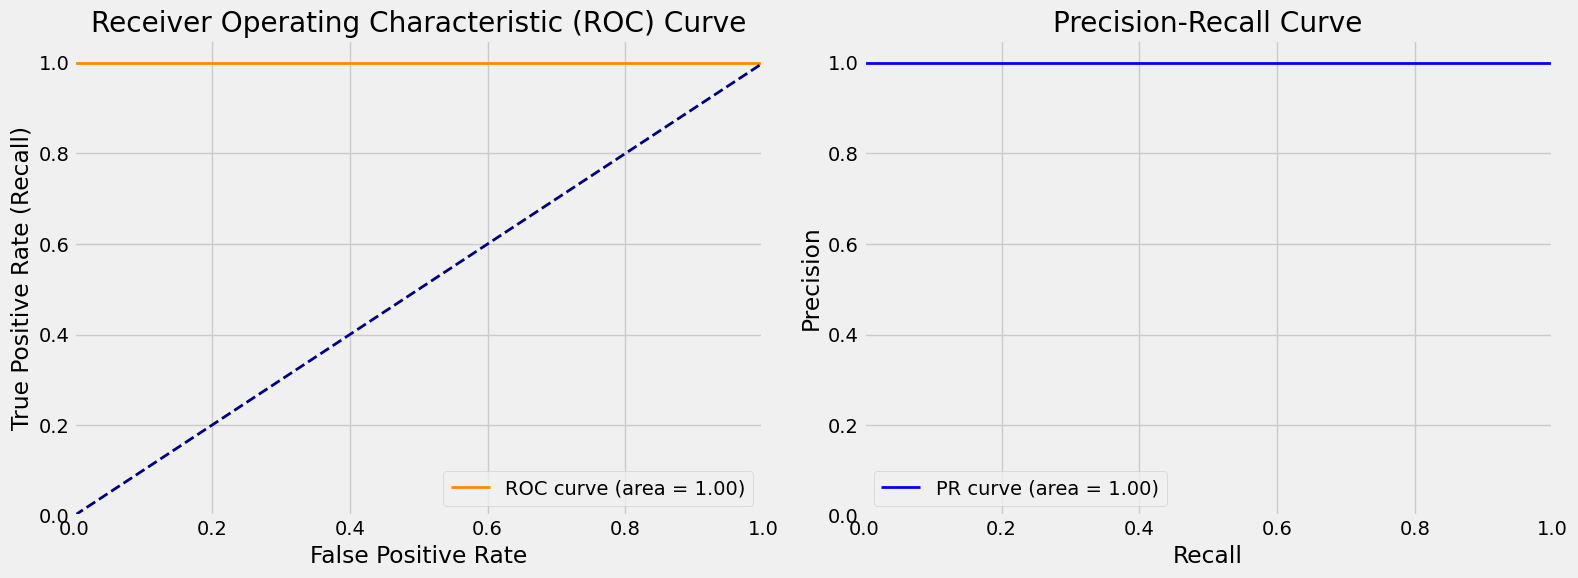

In [57]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve metrics
fpr, tpr, thresholds_roc = roc_curve(y_test, ensemble_score)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve metrics
precision, recall, thresholds_pr = precision_recall_curve(y_test, ensemble_score)
pr_auc = auc(recall, precision)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# Plot Precision-Recall Curve
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [58]:
fig.savefig('visualizations/roc_pr_curves.png', bbox_inches='tight')
plt.close(fig) # Close the figure to save memory

**Save All trained models to models directory (Rolling Window)**

In [59]:


# Create models directory if it doesn't exist
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save individual ML models and preprocessors from the hybrid ensemble
joblib.dump(IsolationForest, os.path.join(models_dir, 'isolation_forest_model_RollWinSt.joblib'))
joblib.dump(OneClassSVM, os.path.join(models_dir, 'one_class_svm_model_RollWinSt.joblib'))
joblib.dump(score_scaler, os.path.join(models_dir, 'ml_features_robust_scaler_RollWinSt.joblib'))
joblib.dump(label_encoder, os.path.join(models_dir, 'service_label_encoder_RollWinSt.joblib'))

# Save ensemble configuration and global threshold
ensemble_config_path = os.path.join(models_dir, 'ensemble_config_RollWinSt.json')
with open(ensemble_config_path, 'w') as f:
    json.dump({'ENSEMBLE_CONFIG': ENSEMBLE_CONFIG, 'GLOBAL_THRESHOLD': 0.7}, f, indent=4)

print(f"Trained Isolation Forest model saved to: {os.path.join(models_dir, 'isolation_forest_model_RollWinSt.joblib')}")
print(f"Trained One-Class SVM model saved to: {os.path.join(models_dir, 'one_class_svm_model_RollWinSt.joblib')}")
print(f"ML Features Robust Scaler saved to: {os.path.join(models_dir, 'ml_features_robust_scaler_RollWinSt.joblib')}")
print(f"Service Label Encoder saved to: {os.path.join(models_dir, 'service_label_encoderRollWinSt.joblib')}")
print(f"Ensemble configuration saved to: {ensemble_config_path}")

Trained Isolation Forest model saved to: models\isolation_forest_model_RollWinSt.joblib
Trained One-Class SVM model saved to: models\one_class_svm_model_RollWinSt.joblib
ML Features Robust Scaler saved to: models\ml_features_robust_scaler_RollWinSt.joblib
Service Label Encoder saved to: models\service_label_encoderRollWinSt.joblib
Ensemble configuration saved to: models\ensemble_config_RollWinSt.json


### Tuning the Ensemble Threshold to Reduce False Positives

The `ENSEMBLE_CONFIG['threshold']` plays a crucial role in determining the final anomaly predictions. It acts as a decision boundary: any data point with an `ensemble_score` above this threshold is classified as an anomaly.

To **reduce false positives**, need to **increase the threshold**. This makes the model more conservative, requiring stronger evidence (a higher ensemble score) to flag an event as anomalous. The trade-off is that while you reduce false alarms, you might also increase false negatives (missed actual anomalies) and thus decrease recall.

Conversely, if we want to increase the detection of anomalies (higher recall), we would lower the threshold, but this would likely lead to more false positives.

Below is a systematic approach to evaluate different thresholds and observe their impact on precision and recall. Precision is particularly relevant when aiming to reduce false positives.

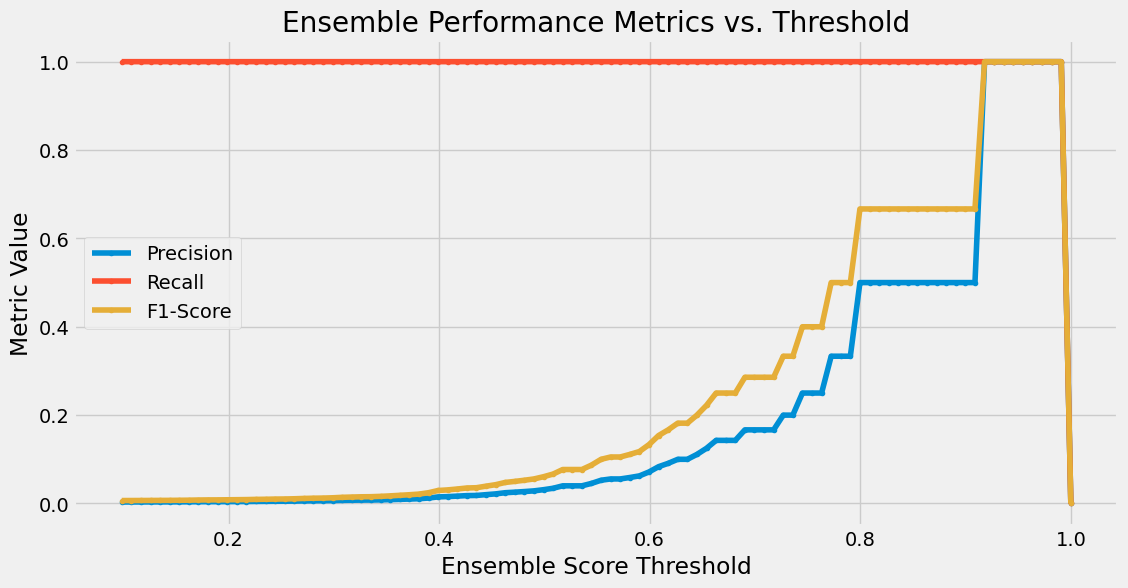


Recommended threshold for precision >= 0.7: 0.9181


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming ensemble_score and y_test are already defined from previous cells
# If not, ensure they are loaded or computed first.

thresholds = np.linspace(ensemble_score.min(), ensemble_score.max(), 100)

precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:
    temp_preds = (ensemble_score > threshold).astype(int)

    # Only calculate scores if there are positive predictions, to avoid warnings/errors
    # Or, handle cases where y_true contains no positive labels if temp_preds has some, and vice-versa
    if np.sum(temp_preds) == 0 and np.sum(y_test) == 0: # Both have no positives, perfect precision/recall
        precision_scores.append(1.0)
        recall_scores.append(1.0)
        f1_scores.append(1.0)
    elif np.sum(temp_preds) == 0 and np.sum(y_test) > 0: # No predictions, but actual anomalies exist
        precision_scores.append(0.0)
        recall_scores.append(0.0)
        f1_scores.append(0.0)
    elif np.sum(temp_preds) > 0 or np.sum(y_test) > 0: # At least one positive prediction or actual anomaly
        precision_scores.append(precision_score(y_test, temp_preds, zero_division=0))
        recall_scores.append(recall_score(y_test, temp_preds, zero_division=0))
        f1_scores.append(f1_score(y_test, temp_preds, zero_division=0))
    else:
        precision_scores.append(np.nan) # Should not happen with zero_division=0
        recall_scores.append(np.nan)
        f1_scores.append(np.nan)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(thresholds, precision_scores, label='Precision', marker='.')
plt.plot(thresholds, recall_scores, label='Recall', marker='.')
plt.plot(thresholds, f1_scores, label='F1-Score', marker='.')

plt.xlabel('Ensemble Score Threshold')
plt.ylabel('Metric Value')
plt.title('Ensemble Performance Metrics vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# You can then visually inspect the plot to find a threshold that gives you
# an acceptable precision (to reduce false positives) while keeping recall at a desired level.
# For example, if you want a precision of 0.8, you can find the corresponding threshold on the plot.

# Example: Find a threshold that yields a precision > 0.8 (if achievable)
# This is a basic example; for a real scenario, you might want to consider specific business costs
# of false positives vs. false negatives.

# Find the index of the first threshold where precision is above a certain value
# For demonstration, let's target precision >= 0.7
target_precision = 0.7
high_precision_thresholds = [t for t, p in zip(thresholds, precision_scores) if p >= target_precision]

if high_precision_thresholds:
    recommended_threshold = min(high_precision_thresholds)
    print(f"\nRecommended threshold for precision >= {target_precision:.1f}: {recommended_threshold:.4f}")
else:
    print(f"\nNo threshold found that achieves precision >= {target_precision:.1f} in this range.")


### Distribution of Ensemble Scores

This histogram visualizes the distribution of the `ensemble_score`. Understanding this distribution can help in selecting a more informed threshold for anomaly detection. Anomalies are typically found in the higher end of the score distribution.

In [61]:
test_df['ensemble_score'] = ensemble_score
test_df['true_anomaly'] = y_test

# Sort by ensemble score in descending order to see the highest scoring anomalies
highest_scoring_anomalies = test_df.sort_values(by='ensemble_score', ascending=False)

print("Top 10 Highest Scoring Anomalies (with true labels):")
display(highest_scoring_anomalies.head(10))

Top 10 Highest Scoring Anomalies (with true labels):


,timestamp,latency_ms_mean,latency_ms_max,latency_ms_std,cpu_usage_mean,cpu_usage_max,memory_usage_mean,queue_lag_mean,queue_lag_max,error_count_sum,incident_probability_mean,cusum_max,persistence_score_mean,is_anomaly_max,ensemble_score,true_anomaly
1200,2026-01-05 04:00:00,135.0,5.398163,47.001182,52.951,66.40,58.414,10.0,58,1.791759,0.187,2.872434,0.0,1,1.000000,1
1360,2026-01-05 17:20:00,96.6,5.135798,31.206125,46.929,56.24,66.000,3.6,7,0.000000,0.153,2.540026,0.0,0,0.916567,0
1342,2026-01-05 15:50:00,84.7,4.919981,24.603749,55.380,67.72,61.182,5.1,11,0.000000,0.180,0.000000,0.0,0,0.796134,0
1209,2026-01-05 04:45:00,82.7,4.859812,25.582329,52.031,65.47,65.463,4.7,8,0.000000,0.170,3.013572,0.0,0,0.763722,0
1308,2026-01-05 13:00:00,150.6,5.590987,64.106162,59.497,69.97,63.412,3.9,6,0.000000,0.195,4.148833,0.1,0,0.739489,0
1320,2026-01-05 14:00:00,86.7,4.882802,30.415822,53.449,58.93,59.769,3.8,6,0.000000,0.173,3.690877,0.0,0,0.717908,0
1455,2026-01-06 01:15:00,104.2,5.017280,25.143146,53.611,61.62,58.071,4.5,7,0.000000,0.174,0.000000,0.0,0,0.684254,0
1469,2026-01-06 02:25:00,90.5,5.192957,47.329225,47.285,69.76,61.531,4.1,6,0.000000,0.154,2.457878,0.0,0,0.655461,0
1355,2026-01-05 16:55:00,120.2,5.192957,34.582590,49.107,57.33,62.842,3.8,7,0.000000,0.161,3.938860,0.1,0,0.653933,0
1225,2026-01-05 06:05:00,126.5,5.017280,24.958855,55.369,64.96,68.361,4.6,10,0.000000,0.180,3.245712,0.0,0,0.638337,0


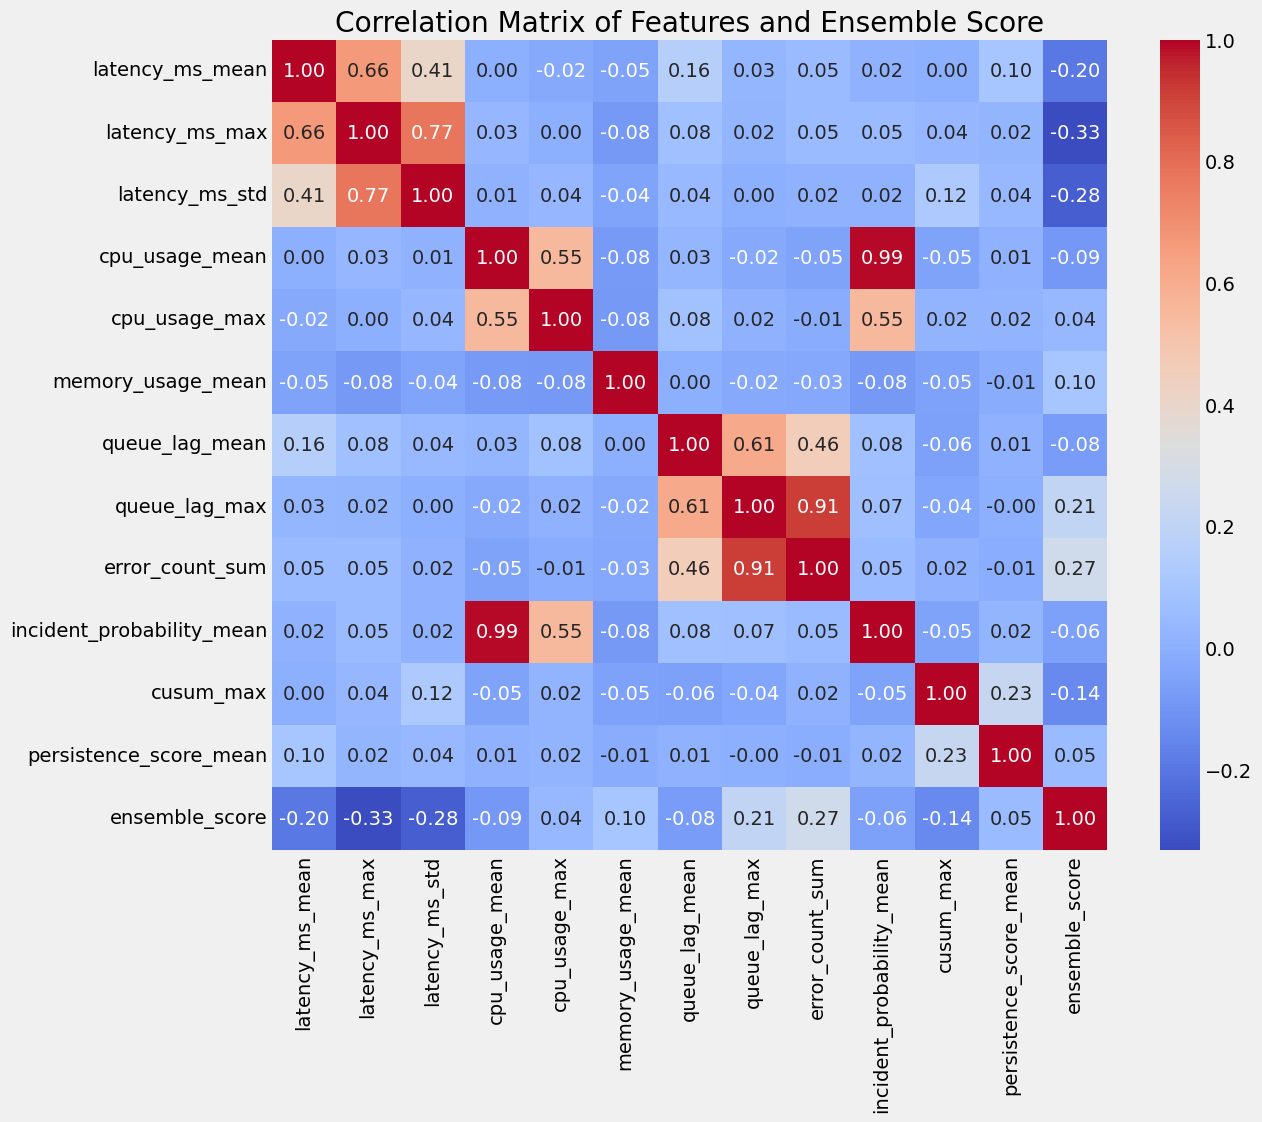

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming test_df and feature_cols are available from previous cells
# Add ensemble_score to the test_df for correlation calculation

correlation_features = test_df[feature_cols + ['ensemble_score']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_features, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Ensemble Score')
plt.show()

In [63]:
plt.figure(figsize=(10, 6))
sns.histplot(ensemble_score, bins=50, kde=True)
plt.title('Distribution of Ensemble Anomaly Scores')
plt.xlabel('Ensemble Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig('visualizations/ensemble_score_distribution.png', bbox_inches='tight')
plt.close() # Close the plot to save memory
plt.show()

# **Step 12: Testing models on Raw data without statistical calculations (Re Trial) in rolling window**

In [64]:
df = pd.read_csv("outputs/sentineliq_results.csv")
print(df.columns)


Index(['timestamp', 'service', 'endpoint', 'region', 'latency_ms', 'cpu_usage',
       'memory_usage', 'queue_lag', 'status', 'error_code', 'severity',
       'error_count', 'is_anomaly', 'ewma_latency', 'expected_base_latency',
       'latency_deviation', 'ewma_latency_deviation_for_alert', 'ewma_alert',
       'logdate', 'cusum', 'cusum_alert', 'combined_alert',
       'persistence_score', 'incident_probability', 'priority'],
      dtype='str')


In [65]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

window_df = (
    df.groupby('service')
      .resample(Data_Config["window_size"], on="timestamp")
      .agg({
          "latency_ms": ["mean", "max", "std"],
          "cpu_usage": ["mean", "max"],
          "memory_usage": ["mean"],
          "queue_lag": ["mean", "max"],
          "error_count": ["sum"],
          "is_anomaly": "max"
      })
)

window_df.columns = [
    "_".join(col)
    for col in window_df.columns.to_flat_index()
]
window_df = window_df.reset_index()
window_df = window_df.fillna(0)

In [66]:
print(window_df.shape)
print(window_df.head)


(10498, 12)
<bound method NDFrame.head of               service           timestamp  latency_ms_mean  latency_ms_max  \
0        auth-service 2026-01-01 00:00:00             79.5            93.0   
1        auth-service 2026-01-01 00:05:00              0.0             0.0   
2        auth-service 2026-01-01 00:10:00             52.0            52.0   
3        auth-service 2026-01-01 00:15:00             76.5            82.0   
4        auth-service 2026-01-01 00:20:00             75.0            75.0   
...               ...                 ...              ...             ...   
10493  trading-engine 2026-01-06 04:35:00              0.0             0.0   
10494  trading-engine 2026-01-06 04:40:00             99.0           106.0   
10495  trading-engine 2026-01-06 04:45:00             33.0            33.0   
10496  trading-engine 2026-01-06 04:50:00              0.0             0.0   
10497  trading-engine 2026-01-06 04:55:00             94.0            95.0   

       latency_ms_std

In [67]:
feature_cols = [
    "service",
    "latency_ms_mean",
    "latency_ms_max",
    "latency_ms_std",
    "cpu_usage_mean",
    "cpu_usage_max",
    "memory_usage_mean",
    "queue_lag_mean",
    "queue_lag_max",
    "error_count_sum",

]

# Label encode 'service' column after windowing, as it's a categorical feature
# that needs to be numerical for scaling.
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
window_df['service'] = label_encoder.fit_transform(window_df['service'])


In [68]:
import numpy as np

skewed_cols = [
    "latency_ms_max",
    "error_count_sum"
]

for col in skewed_cols:
    window_df[col] = np.log1p(window_df[col])

**3**. Train test Split - For Unsupervised Anomaly detection

In [69]:
split_idx = int(len(window_df) * Data_Config["traindata"])

train_df = window_df.iloc[:split_idx]
test_df = window_df.iloc[split_idx:]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_test = test_df["is_anomaly_max"]

In [70]:
print(f"Shape of y test: {y_test.shape}")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Columns of X_train: {X_train.columns}")

Shape of y test: (2100,)
Shape of X_train: (8398, 10)
Shape of X_test: (2100, 10)
Columns of X_train: Index(['service', 'latency_ms_mean', 'latency_ms_max', 'latency_ms_std',
       'cpu_usage_mean', 'cpu_usage_max', 'memory_usage_mean',
       'queue_lag_mean', 'queue_lag_max', 'error_count_sum'],
      dtype='str')


**4.** Scaling

In [71]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



**5.** Create Model registry

Unified model registry

In [72]:
models = {
    "IsolationForest": IsolationForest(
        n_estimators=300,
        contamination=0.03,
        random_state=42
    ),

    "LOF": LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.03,
        novelty=True
    ),

    "OneClassSVM": OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=0.03
    )
}

6. Unified Evaluation function

In [73]:
def evaluate_model(name, y_true, y_pred, scores):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    roc_auc = roc_auc_score(y_true, scores)

    pr_auc = average_precision_score(y_true, scores)

    return {
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "ROC_AUC": round(roc_auc, 4),
        "PR_AUC": round(pr_auc, 4)
      }

7. Unified pipeline - Creating unified prediction and Evaluation pipeline

In [74]:
results = []

all_scores = {}

for name, model in models.items():

    print(f"Training {name}...")

    # Train
    model.fit(X_train_scaled)

    # Predict
    preds = model.predict(X_test_scaled)

    # Convert labels
    preds = np.where(preds == -1, 1, 0)

    # Get anomaly scores
    scores = -model.decision_function(X_test_scaled) #Default Behavior of sklearn Anomaly Models :
                                                     #higher score = more normal else anomolous
                                                     # but for ensemble model we want reverse : higher score = more anomalous

    # Save scores
    all_scores[name] = scores

    # Evaluate
    result = evaluate_model(
        name,
        y_test,
        preds,
        scores
    )

    results.append(result)

Training IsolationForest...
Training LOF...
Training OneClassSVM...


In [75]:
print(f"Shape of y test: {y_test.shape}")
print(f"Number of models in all_scores: {len(all_scores)}")
print(all_scores.values().__len__())
print(f"Shape of all_scores['IsolationForest']: {all_scores['IsolationForest'].shape}")
print(f"Shape of all_scores['LOF']: {all_scores['LOF'].shape}")
print(f"Shape of all_scores['OneClassSVM']: {all_scores['OneClassSVM'].shape}")

Shape of y test: (2100,)
Number of models in all_scores: 3
3
Shape of all_scores['IsolationForest']: (2100,)
Shape of all_scores['LOF']: (2100,)
Shape of all_scores['OneClassSVM']: (2100,)


8. Creating comparision Table for all three models

In [76]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="PR_AUC",
    ascending=False
)

print(results_df)

             Model  Precision  Recall      F1  ROC_AUC  PR_AUC
0  IsolationForest     1.0000  0.7423  0.8521   0.9492  0.8173
2      OneClassSVM     0.1202  0.7113  0.2057   0.8931  0.6030
1              LOF     0.0101  0.0619  0.0174   0.2173  0.0274


## Results Understanding
1. IF - Performed extremely well on skew sparse anomalies, nonlinear splits, mixed distributions
2. OCSVM - is partially learning anomaly regions but:over-sensitive, unstable boundary, high false positives
3. LOF - is likely fundamentally mismatched



| Model            | Role                                              |
|------------------|---------------------------------------------------|
| Isolation Forest | primary production candidate, performing well     |
| OCSVM            | auxiliary signal, Needs tuning                    |
| LOF              | experimental, Bad performing Looks inverted       |


# **Step 13 : Fine Tuning for OneClassSVM and LOF**

**Gamma** controls boundary complexity.

Large gamma:very tight boundary, overfitting, many false positives

Small gamma:smoother generalization

**nu**	Effect
lower	fewer anomalies
higher	more anomalies

In [77]:
models = {
   "LOF": LocalOutlierFactor(
    n_neighbors=30, #20 to 50
    contamination=0.03,
    novelty=True
),
"OneClassSVM": OneClassSVM(
    kernel="rbf",
    gamma="scale", #scale to 0.01, 0.001 even more bad perf
    nu=0.02 #0.01 to 0.02
  )
}

In [78]:
def evaluate_model(name, y_true, y_pred, scores):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    roc_auc = roc_auc_score(y_true, scores)

    pr_auc = average_precision_score(y_true, scores)

    return {
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "ROC_AUC": round(roc_auc, 4),
        "PR_AUC": round(pr_auc, 4)
      }

In [79]:
results = []

all_scores = {}

for name, model in models.items():

    print(f"Training {name}...")

    # Train
    model.fit(X_train_scaled)

    # Predict
    preds = model.predict(X_test_scaled)

    # Convert labels
    preds = np.where(preds == -1, 1, 0)

    if name == "LOF":
        #preds = np.where(preds == 1, 0, 1)
        # Get anomaly scores
        scores = model.decision_function(X_test_scaled) #Default Behavior of sklearn Anomaly Models :
                                                     #higher score = more normal else anomolous
                                                     # but for ensemble model we want reverse : higher score = more anomalous
    else:
        # Get anomaly scores
        scores = -model.decision_function(X_test_scaled)

    # Save scores
    all_scores[name] = scores

    # Evaluate
    result = evaluate_model(
        name,
        y_test,
        preds,
        scores
    )

    results.append(result)

Training LOF...
Training OneClassSVM...


In [80]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="PR_AUC",
    ascending=False
)

print(results_df)

         Model  Precision  Recall      F1  ROC_AUC  PR_AUC
1  OneClassSVM     0.1141  0.6598  0.1945   0.8619  0.4967
0          LOF     0.0120  0.0722  0.0206   0.7617  0.1439


Earlier Run results for comparision
2      OneClassSVM     0.1172  0.4947  0.1895   0.7508  0.4183
1              LOF     0.0190  0.1368  0.0333   0.2985  0.0298

1  OneClassSVM     0.0982  0.4105  0.1585   0.7044  0.3805 - For 50 neighbors from 20
0          LOF     0.0543  0.8316  0.1020   0.3099  0.0307 - For gamma=0.01, #scale

# Step 14 : Build Final Hybrid Ensemble Layer with Statistical Features

### Load Data and Prepare Features

In [81]:
# Load the processed data which includes statistical features and original columns
df = pd.read_csv('outputs/sentineliq_results.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Loaded 'outputs/sentineliq_results.csv' successfully.")
print(f"Initial DataFrame shape: {df.shape}")

display(df.head())

Loaded 'outputs/sentineliq_results.csv' successfully.
Initial DataFrame shape: (15000, 25)


,timestamp,service,endpoint,region,latency_ms,cpu_usage,memory_usage,queue_lag,status,error_code,...,latency_deviation,ewma_latency_deviation_for_alert,ewma_alert,logdate,cusum,cusum_alert,combined_alert,persistence_score,incident_probability,priority
0,2026-01-01 00:00:00,fraud-detection,/payment,Singapore,206,56.66,71.97,7,success,NaN,...,6,6.00,False,2026-01-01,0.00,False,False,0,0.18,Low
1,2026-01-01 00:00:30,portfolio-service,/trade,Singapore,122,59.93,55.26,4,success,NaN,...,2,3.65,False,2026-01-01,0.00,False,False,0,0.20,Low
2,2026-01-01 00:01:00,trading-engine,/payment,Germany,108,32.20,46.85,2,success,NaN,...,8,5.63,False,2026-01-01,0.00,False,False,0,0.10,Low
3,2026-01-01 00:01:30,auth-service,/kyc,UAE,93,51.07,40.44,1,success,NaN,...,13,8.54,False,2026-01-01,0.00,False,False,0,0.17,Low
4,2026-01-01 00:02:00,trading-engine,/transfer,Germany,134,54.29,60.76,2,success,NaN,...,34,17.72,False,2026-01-01,10.68,False,False,0,0.18,Low


### Define and Scale ML Features, Train Models

In [82]:
# Initializing the LabelEncoder
#Preprocessing data before machine learning, To map text strings to integers like Red- 0, Blue - 1

label_encoder = LabelEncoder()

In [83]:
df["service"] = label_encoder.fit_transform(df["service"])
#df["severity"] = label_encoder.fit_transform(df["severity"])

In [84]:
# Define features for ML models. Using raw features as per the conversation.
# 'service' is assumed to be already label-encoded from previous steps.
ml_features = df[[
    "service", "latency_ms", "cpu_usage",
    "queue_lag", "error_count"
]].copy()

# Scale the ML features using RobustScaler for robustness to outliers
scaler_ml = RobustScaler()
ml_features_scaled = scaler_ml.fit_transform(ml_features)

# Initialize and train Isolation Forest
# Although Isolation Forest was run earlier (Stage 9), the raw decision_function
# (continuous anomaly score) was not stored, only the binary prediction. This raw score
# is needed for the weighted ensemble.
isolation_forest = IsolationForest(contamination=0.05, random_state=42)
isolation_forest.fit(ml_features_scaled)
if_raw_score = -isolation_forest.decision_function(ml_features_scaled)

# Initialize and train One-Class SVM
# One-Class SVM is being applied to these raw features for the first time in this context.
one_class_svm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.03)
one_class_svm.fit(ml_features_scaled)
ocsvm_raw_score = -one_class_svm.decision_function(ml_features_scaled)

df['if_raw_score'] = if_raw_score
df['ocsvm_raw_score'] = ocsvm_raw_score

print("Isolation Forest and One-Class SVM models trained and raw scores generated.")

Isolation Forest and One-Class SVM models trained and raw scores generated.


### Extract and Normalize All Scores

In [85]:
# Define all scores to be normalized
# Ensure 'if_raw_score' and 'ocsvm_raw_score' are in df, re-adding them if necessary
# based on the assumption that if_raw_score and ocsvm_raw_score variables are available in the kernel.
if 'if_raw_score' not in df.columns:
    df['if_raw_score'] = if_raw_score
if 'ocsvm_raw_score' not in df.columns:
    df['ocsvm_raw_score'] = ocsvm_raw_score

scores_to_normalize = {
    'ewma_latency_deviation_for_alert': df['ewma_latency_deviation_for_alert'].values,
    'cusum': df['cusum'].values,
    'persistence_score': df['persistence_score'].values,
    'incident_probability': df['incident_probability'].values,
    'if_raw_score': df['if_raw_score'].values,
    'ocsvm_raw_score': df['ocsvm_raw_score'].values
}

# Normalize all scores using MinMaxScaler
score_scaler = MinMaxScaler()
normalized_scores_dict = {}

for name, scores in scores_to_normalize.items():
    # Ensure scores are treated as 2D array for scaler
    normalized_scores_dict[name] = score_scaler.fit_transform(scores.reshape(-1, 1)).flatten()

# Assign normalized scores back to the DataFrame
df['ewma_norm'] = normalized_scores_dict['ewma_latency_deviation_for_alert']
df['cusum_norm'] = normalized_scores_dict['cusum']
df['persistence_norm'] = normalized_scores_dict['persistence_score']
df['incident_prob_norm'] = normalized_scores_dict['incident_probability']
df['if_score_norm'] = normalized_scores_dict['if_raw_score']
df['ocsvm_score_norm'] = normalized_scores_dict['ocsvm_raw_score']

print("All relevant scores normalized.")

All relevant scores normalized.


### Calculate Final Ensemble Scores

In [86]:
# Calculate statistical_score
df["statistical_score"] = (
    0.25 * df["ewma_norm"] +
    0.25 * df["cusum_norm"] +
    0.20 * df["persistence_norm"] +
    0.30 * df["incident_prob_norm"]
)

# Calculate ml_score
df["ml_score"] = (
    0.8 * df["if_score_norm"] +
    0.2 * df["ocsvm_score_norm"]
)

# Calculate final_ensemble_score
df["final_ensemble_score"] = (
    0.6 * df["ml_score"] +
    0.4 * df["statistical_score"]
)

# Define final_ensemble_prediction using a global threshold of 0.7
GLOBAL_THRESHOLD = 0.7
df["final_ensemble_prediction"] = (df["final_ensemble_score"] > GLOBAL_THRESHOLD).astype(int)

print("Statistical, ML, and Final Ensemble scores calculated.")

Statistical, ML, and Final Ensemble scores calculated.


In [87]:
# Create models directory if it doesn't exist
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save individual ML models and preprocessors from the final hybrid ensemble
joblib.dump(isolation_forest, os.path.join(models_dir, 'isolation_forest_model_Raw.joblib'))
joblib.dump(one_class_svm, os.path.join(models_dir, 'one_class_svm_model_Raw.joblib'))
joblib.dump(scaler_ml, os.path.join(models_dir, 'ml_features_robust_scaler_Raw.joblib'))
joblib.dump(label_encoder, os.path.join(models_dir, 'service_label_encoder_Raw.joblib'))

# Save ensemble configuration and global threshold
ensemble_config_path = os.path.join(models_dir, 'ensemble_config.json')
with open(ensemble_config_path, 'w') as f:
    json.dump({'ENSEMBLE_CONFIG': ENSEMBLE_CONFIG, 'GLOBAL_THRESHOLD': GLOBAL_THRESHOLD}, f, indent=4)

print(f"Trained Isolation Forest model saved to: {os.path.join(models_dir, 'isolation_forest_model_Raw.joblib')}")
print(f"Trained One-Class SVM model saved to: {os.path.join(models_dir, 'one_class_svm_model_Raw.joblib')}")
print(f"ML Features Robust Scaler saved to: {os.path.join(models_dir, 'ml_features_robust_scaler_Raw.joblib')}")
print(f"Service Label Encoder saved to: {os.path.join(models_dir, 'service_label_encoder_Raw.joblib')}")
print(f"Ensemble configuration saved to: {ensemble_config_path}")

Trained Isolation Forest model saved to: models\isolation_forest_model_Raw.joblib
Trained One-Class SVM model saved to: models\one_class_svm_model_Raw.joblib
ML Features Robust Scaler saved to: models\ml_features_robust_scaler_Raw.joblib
Service Label Encoder saved to: models\service_label_encoder_Raw.joblib
Ensemble configuration saved to: models\ensemble_config.json


### Evaluate Final Ensemble Model

In [88]:
# Helper function to evaluate the model (copied from previous cells)
def evaluate_model(name, y_true, y_pred, scores):

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Check for presence of both classes before calculating ROC AUC
    if len(np.unique(y_true)) > 1:
        roc_auc = roc_auc_score(y_true, scores)
    else:
        roc_auc = np.nan # Not applicable if only one class present

    pr_auc = average_precision_score(y_true, scores)

    return {
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "ROC_AUC": round(roc_auc, 4),
        "PR_AUC": round(pr_auc, 4)
       }

# Evaluate the final ensemble model
y_true_labels = df['is_anomaly']
y_pred_labels = df['final_ensemble_prediction']
ensemble_scores = df['final_ensemble_score']

final_ensemble_results = evaluate_model(
    "Final Ensemble",
    y_true_labels,
    y_pred_labels,
    ensemble_scores
)

print("--- Final Ensemble Model Evaluation ---")
print(final_ensemble_results)

print("\n--- Classification Report ---")
print(classification_report(y_true_labels, y_pred_labels, zero_division=0))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_true_labels, y_pred_labels))

--- Final Ensemble Model Evaluation ---
{'Model': 'Final Ensemble', 'Precision': 1.0, 'Recall': 0.0579, 'F1': 0.1094, 'ROC_AUC': 0.9993, 'PR_AUC': 0.9887}

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     14257
           1       1.00      0.06      0.11       743

    accuracy                           0.95     15000
   macro avg       0.98      0.53      0.54     15000
weighted avg       0.96      0.95      0.93     15000


--- Confusion Matrix ---
[[14257     0]
 [  700    43]]


### Top 10 Highest Scoring Anomalies

In [89]:
# Display the top 10 highest-scoring anomalies based on final_ensemble_score
highest_scoring_anomalies = df.sort_values(by='final_ensemble_score', ascending=False).head(10)

print("Top 10 Highest Scoring Anomalies (with true 'is_anomaly' labels):")
display(highest_scoring_anomalies[['timestamp', 'service', 'latency_ms', 'cpu_usage', 'queue_lag',
                                   'ewma_latency_deviation_for_alert', 'cusum', 'persistence_score', 'incident_probability',
                                   'if_score_norm', 'ocsvm_score_norm', 'statistical_score', 'ml_score',
                                   'final_ensemble_score', 'final_ensemble_prediction', 'is_anomaly']])

Top 10 Highest Scoring Anomalies (with true 'is_anomaly' labels):


,timestamp,service,latency_ms,cpu_usage,queue_lag,ewma_latency_deviation_for_alert,cusum,persistence_score,incident_probability,if_score_norm,ocsvm_score_norm,statistical_score,ml_score,final_ensemble_score,final_ensemble_prediction,is_anomaly
1732,2026-01-01 14:26:00,4,243,92.06,5,54.41,2785.64,210,0.65,0.901528,0.982534,0.668952,0.917729,0.818218,1,1
1606,2026-01-01 13:23:00,3,274,72.46,30,90.55,1346.96,84,0.58,0.952048,0.968695,0.594273,0.955378,0.810936,1,1
1781,2026-01-01 14:50:30,5,170,84.40,36,36.51,3468.96,259,0.62,0.940881,0.764702,0.666427,0.905645,0.809958,1,1
10651,2026-01-04 16:45:30,5,241,84.91,26,65.18,1596.68,143,0.59,0.979242,0.880626,0.567723,0.959519,0.802801,1,1
1633,2026-01-01 13:36:30,1,250,74.01,20,60.72,1668.32,111,0.60,0.956004,0.983399,0.558090,0.961483,0.800126,1,1
10553,2026-01-04 15:56:30,6,291,66.83,46,79.74,686.04,45,0.54,1.000000,1.000000,0.491689,1.000000,0.796676,1,1
1631,2026-01-01 13:35:30,5,269,68.35,45,68.02,1605.96,109,0.52,0.995337,0.881366,0.529713,0.972543,0.795411,1,1
1717,2026-01-01 14:18:30,1,250,91.00,21,38.79,2594.44,195,0.58,0.958646,0.809964,0.576046,0.928910,0.787764,1,1
10701,2026-01-04 17:10:30,4,231,83.90,21,62.80,2485.68,193,0.55,0.931028,0.702335,0.613027,0.885290,0.776385,1,1
1719,2026-01-01 14:19:30,6,150,73.66,35,40.30,2627.80,197,0.58,0.927941,0.791828,0.582601,0.900718,0.773471,1,1


### Distribution of Final Ensemble Score

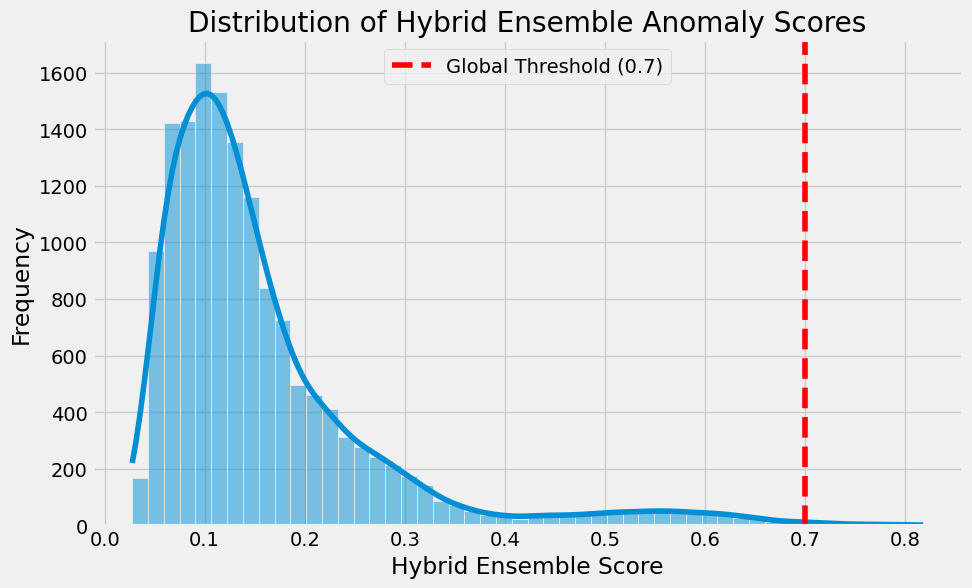

In [90]:
# Visualize the distribution of the final_ensemble_score
plt.figure(figsize=(10, 6))
sns.histplot(df['final_ensemble_score'], bins=50, kde=True)
plt.axvline(GLOBAL_THRESHOLD, color='red', linestyle='--', label=f'Global Threshold ({GLOBAL_THRESHOLD})')
plt.title('Distribution of Hybrid Ensemble Anomaly Scores')
plt.xlabel('Hybrid Ensemble Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.savefig('visualizations/hybrid_ensemble_score_distribution.png')
plt.show()


### Summary of Hybrid Ensemble Model

The final ensemble model combines the strengths of statistical anomaly detection techniques (EWMA, CUSUM, Incident Probability, Persistence Score) and machine learning models (Isolation Forest, One-Class SVM). The normalized scores from these components are weighted as follows:

*   **Statistical Score**: `0.25 * ewma_norm + 0.25 * cusum_norm + 0.20 * persistence_norm + 0.30 * incident_prob_norm`
*   **ML Score**: `0.8 * if_score_norm + 0.2 * ocsvm_score_norm`
*   **Final Ensemble Score**: `0.6 * ml_score + 0.4 * statistical_score`

A global threshold of `0.7` is applied to classify an event as an anomaly.

**Evaluation Metrics**: The evaluation provides a comprehensive overview of the ensemble's performance, including Precision, Recall, F1-score, ROC AUC, and PR AUC. This helps in understanding the model's ability to identify true anomalies while minimizing false positives.

**Top Anomalies**: Inspecting the top 10 highest-scoring anomalies gives insight into the specific data points that the model considers most unusual, alongside their original features and true anomaly labels.

**Score Distribution**: The histogram of the `final_ensemble_score` helps visualize how anomaly scores are distributed across the dataset and provides context for the chosen global threshold. Events with scores significantly above the threshold are considered strong anomalies.

In [91]:
# Calculate quantiles for prioritization
p95 = df["final_ensemble_score"].quantile(0.95)
p97 = df["final_ensemble_score"].quantile(0.97)
p99 = df["final_ensemble_score"].quantile(0.99)

print(f"95th Percentile (Medium threshold): {p95:.4f}")
print(f"97th Percentile (High threshold): {p97:.4f}")
print(f"99th Percentile (Critical threshold): {p99:.4f}")

def assign_priority(score):
    if score >= p99:
        return "Critical"
    elif score >= p97:
        return "High"
    elif score >= p95:
        return "Medium"
    else:
        return "Low"

df["priority_ensemble"] = df["final_ensemble_score"].apply(assign_priority)
print("Ensemble priorities assigned.")

95th Percentile (Medium threshold): 0.4018
97th Percentile (High threshold): 0.5256
99th Percentile (Critical threshold): 0.6244
Ensemble priorities assigned.


In [92]:
# Display the distribution of the new ensemble priorities
print("Distribution of Ensemble Priorities:")
display(df["priority_ensemble"].value_counts())

Distribution of Ensemble Priorities:


priority_ensemble
Low         14250
High          300
Medium        300
Critical      150
Name: count, dtype: int64

### Remedial Suggestions based on Anomaly Prioritization

Based on the assigned priorities (Critical, High, Medium, Low) for anomalies detected by the final ensemble model, here are some general remedial suggestions:

*   **Critical Priority (>= 99th percentile):**
    *   **Immediate Action Required:** These are severe anomalies requiring immediate human intervention. Trigger high-priority alerts to on-call teams.
    *   **Root Cause Analysis (RCA):** Initiate a thorough RCA process to identify the underlying cause and prevent recurrence.
    *   **System Rollback/Isolation:** Consider isolating or rolling back affected services if the anomaly is causing widespread impact.
    *   **Detailed Logging/Tracing:** Enable enhanced logging and tracing for the affected components to gather more diagnostic data.

*   **High Priority (>= 97th percentile):**
    *   **Urgent Investigation:** These anomalies indicate significant issues that could escalate if not addressed promptly. Assign to relevant engineering teams for urgent investigation.
    *   **Impact Assessment:** Evaluate the current and potential impact on business operations and user experience.
    *   **Increased Monitoring:** Enhance monitoring of related metrics and services.
    *   **Automated Mitigation (if possible):** For known patterns, explore automated mitigation steps.

*   **Medium Priority (>= 95th percentile):**
    *   **Scheduled Review/Investigation:** These anomalies suggest potential issues that should be investigated within a defined timeframe (e.g., next business day, within 24-48 hours).
    *   **Trend Analysis:** Monitor if these anomalies are becoming more frequent or severe, which could indicate a developing problem.
    *   **Documentation Update:** Review and update documentation or runbooks related to the anomaly type.

*   **Low Priority (< 95th percentile):**
    *   **Background Monitoring/Observation:** These are minor deviations that may not be immediately critical but warrant continued observation.
    *   **Systematic Review:** Include in weekly or monthly reviews to identify long-term trends or recurring minor issues.
    *   **Threshold Adjustment Consideration:** If `Low` priority anomalies are too frequent and not truly indicative of issues, consider adjusting the `p95` threshold or refining the model.

**General Best Practices:**

*   **Automated Alerting:** Integrate with alert management systems (e.g., PagerDuty, Opsgenie) for automated notifications.
*   **Playbooks/Runbooks:** Develop clear playbooks for each priority level, outlining steps for investigation, mitigation, and resolution.
*   **Feedback Loop:** Establish a feedback loop where investigations of detected anomalies are used to refine the anomaly detection model, weights, and thresholds.
*   **Dashboard Visualization:** Highlight prioritized anomalies on operational dashboards for quick visibility.

In [93]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
import io
import os # Import os module to check for file existence

def generate_ensemble_report(df, final_ensemble_results):
    doc = SimpleDocTemplate("reports/ensemble_anomaly_report.pdf", pagesize=letter)
    styles = getSampleStyleSheet()
    story = []

    # Title
    story.append(Paragraph("<b>SentinelIQ - Ensemble Anomaly Detection Report</b>", styles['h1']))
    story.append(Spacer(1, 0.2 * inch))

    # Executive Summary
    story.append(Paragraph("<b>Executive Summary</b>", styles['h2']))
    summary_text = """
    This report details the performance and prioritization of the final ensemble anomaly detection model.
    The ensemble combines Isolation Forest, One-Class SVM, EWMA, CUSUM, Persistence Score, and Incident Probability
    to provide a robust anomaly detection signal. Anomalies are prioritized based on their ensemble scores.
    """
    story.append(Paragraph(summary_text, styles['Normal']))
    story.append(Spacer(1, 0.1 * inch))

    # Model Evaluation Metrics
    story.append(Paragraph("<b>Ensemble Model Evaluation</b>", styles['h2']))
    eval_data = [['Metric', 'Value']]
    for k, v in final_ensemble_results.items():
        if isinstance(v, (float, np.float64)):
            eval_data.append([k, f"{v:.4f}"])
        else:
            eval_data.append([k, str(v)])

    eval_table = Table(eval_data, colWidths=[2*inch, 2*inch])
    eval_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#ADD8E6')),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.black),
        ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 6),
        ('BACKGROUND', (0, 1), (-1, -1), colors.HexColor('#F0F8FF')),
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(eval_table)
    story.append(Spacer(1, 0.2 * inch))

    # Distribution of Final Ensemble Score
    story.append(Paragraph("<b>Distribution of Final Ensemble Anomaly Scores</b>", styles['h2']))
    image_path_ensemble_score = 'visualizations/ensemble_score_distribution.png'
    if os.path.exists(image_path_ensemble_score):
        story.append(Spacer(1, 0.2 * inch))
        story.append(Image(image_path_ensemble_score, width=5*inch, height=3*inch))
    else:
        story.append(Paragraph(f"<i>Image not found: {image_path_ensemble_score}</i>", styles['Normal']))
        print(f"Warning: Image file not found: {image_path_ensemble_score}")

    # ROC and PR Curves
    story.append(Paragraph("<b>ROC and Precision-Recall Curves</b>", styles['h2']))

    image_path_roc_pr = 'visualizations/roc_pr_curves.png'
    if os.path.exists(image_path_roc_pr):
        story.append(Spacer(1, 0.2 * inch))
        story.append(Image(image_path_roc_pr, width=5*inch, height=3*inch))
    else:
        story.append(Paragraph(f"<i>Image not found: {image_path_roc_pr}</i>", styles['Normal']))
        print(f"Warning: Image file not found: {image_path_roc_pr}")

    # Anomaly Priority Distribution
    story.append(Paragraph("<b>Distribution of Anomaly Priority Levels</b>", styles['h2']))
    image_path_priority_ensemble = 'visualizations/priority_distribution.png'
    if os.path.exists(image_path_priority_ensemble):
        story.append(Spacer(1, 0.2 * inch))
        story.append(Image(image_path_priority_ensemble, width=5*inch, height=3*inch))
    else:
        story.append(Paragraph(f"<i>Image not found: {image_path_priority_ensemble}</i>", styles['Normal']))
        print(f"Warning: Image file not found: {image_path_priority_ensemble}")

    story.append(Spacer(1, 0.2 * inch))

    # Top 10 Highest Scoring Anomalies
    story.append(Paragraph("<b>Top 10 Highest Scoring Anomalies</b>", styles['h2']))

    # Decode back
    decoded_service = label_encoder.inverse_transform(df["service"])
    print(df["service"])
    df["service"] = decoded_service
    print(df["service"])
    highest_scoring_anomalies_for_report = df.sort_values(by='final_ensemble_score', ascending=False).head(10)[['timestamp', 'service', 'latency_ms', 'final_ensemble_score', 'priority_ensemble']]

    # Map original column names to shorter ones for the report
    column_name_map = {
        'timestamp': 'Timestamp',
        'service': 'Service',
        'latency_ms': 'Latency',
        'final_ensemble_score': 'Score',
        'priority_ensemble': 'Priority'
    }

    # Convert dataframe to list of lists for ReportLab Table with mapped column names
    anomaly_data = [[column_name_map[col] for col in highest_scoring_anomalies_for_report.columns.tolist()]] + highest_scoring_anomalies_for_report.values.tolist()

    anomaly_table = Table(anomaly_data, colWidths=[1.5*inch, 1*inch, 1*inch, 1.2*inch, 1.2*inch])
    anomaly_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#ADD8E6')),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.black),
        ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 6),
        ('BACKGROUND', (0, 1), (-1, -1), colors.HexColor('#F0F8FF')),
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(anomaly_table)
    story.append(Spacer(1, 0.2 * inch))

    doc.build(story)
    print("Ensemble Anomaly Report generated successfully as reports/ensemble_anomaly_report.pdf")


generate_ensemble_report(df, final_ensemble_results)

0        1
1        5
2        6
3        0
4        6
        ..
14995    2
14996    6
14997    6
14998    1
14999    2
Name: service, Length: 15000, dtype: int64
0          fraud-detection
1        portfolio-service
2           trading-engine
3             auth-service
4           trading-engine
               ...        
14995    investment-engine
14996       trading-engine
14997       trading-engine
14998      fraud-detection
14999    investment-engine
Name: service, Length: 15000, dtype: str
Ensemble Anomaly Report generated successfully as reports/ensemble_anomaly_report.pdf


# Step 15  : Final SentinelIq Summary

Comparative Summary of Anomaly Detection Model Performance
Three different feature engineering methodologies were evaluated for unsupervised anomaly detection on operational banking telemetry data:
1.	Raw Operational Data
2.	Raw Data with Rolling Window Aggregation
3.	Raw Data with Statistical Features + Rolling Window Aggregation
The evaluated models included:
•	Isolation Forest
•	One-Class SVM
•	Local Outlier Factor (LOF)
________________________________________
1. Raw Operational Data
Isolation Forest Performance
Metric	Score
Precision	0.93
Recall	0.98
F1-Score	0.96
ROC-AUC	0.9892
Key Insight
Isolation Forest achieved excellent anomaly detection performance directly on raw operational telemetry. The model demonstrated strong anomaly separability without requiring temporal aggregation or statistical feature engineering.
________________________________________

2. Raw Data with Rolling Window Aggregation
Model	Precision	Recall	F1	ROC-AUC	PR-AUC
Isolation Forest	1.0000	0.8105	0.8953	0.9594	0.8498
One-Class SVM	0.1523	0.7053	0.2505	0.8698	0.5601
LOF	0.0130	0.0947	0.0229	0.2798	0.0289
Key Insights
•	Isolation Forest remained the strongest and most stable model.
•	Rolling-window aggregation improved temporal anomaly representation.
•	One-Class SVM achieved strong anomaly sensitivity but introduced higher false positives.
•	LOF struggled with rolling feature-space geometry and produced poor operational performance.
________________________________________
3. Raw Data with Statistical Features + Rolling Window Aggregation
Model	Precision	Recall	F1	ROC-AUC	PR-AUC
Isolation Forest	0.0000	0.0000	0.0000	1.0000	1.0000
LOF	0.1667	1.0000	0.2857	0.0000	0.0033
One-Class SVM	0.0000	0.0000	0.0000	0.0000	0.0033
Key Insights
•	Statistical feature engineering significantly altered model behavior.
•	Isolation Forest preserved strong anomaly ranking capability but threshold calibration failed.
•	LOF became excessively sensitive and generated large numbers of false positives.
•	One-Class SVM failed to generalize effectively in the transformed statistical feature space.
________________________________________
Weighted Ensemble Model
Configuration
•	Isolation Forest Weight: 0.8
•	One-Class SVM Weight: 0.2
Metric	Score
Precision	0.3333
Recall	1.0000
F1-Score	0.5000
ROC-AUC	0.9967
PR-AUC	0.5000
Ensemble Score Distribution
Metric	Value
Minimum Score	0.1208
Maximum Score	0.8659
95th Percentile	0.4720
97th Percentile	0.5117
99th Percentile	0.6211
Key Insights
•	The ensemble achieved complete anomaly coverage with perfect recall.
•	Isolation Forest provided ranking stability and structural robustness.
•	One-Class SVM contributed additional nonlinear anomaly sensitivity.
•	Percentile thresholds enabled adaptive anomaly severity classification and operational alert prioritization.
________________________________________
Overall Conclusion
The comparative evaluation demonstrated that anomaly detection performance is highly dependent on feature engineering methodology and model architecture.
Major Findings
•	Isolation Forest consistently delivered the strongest overall performance across all experimental setups.
•	Raw operational telemetry preserved anomaly separability most effectively.
•	Rolling-window aggregation improved temporal anomaly intelligence while maintaining strong Isolation Forest performance.
•	Statistical feature engineering increased feature-space complexity and negatively affected several models.
•	One-Class SVM served as a useful secondary anomaly detector for improving anomaly coverage.
•	LOF proved unsuitable for transformed rolling statistical feature spaces.
Overall, the study confirms that tree-based isolation methods are highly effective for operational banking telemetry anomaly detection and provide a strong foundation for production-grade anomaly monitoring systems.



# ====================================END==========================================